# U-MobileViT-Net **PRO** — Model Dissection & Layer-wise Activation Heatmaps

**Dataset**: COCO Tea Leaf | 8-class synthetic agricultural disease segmentation  
**Model**: U-MobileViT-Net **Pro** (d_model=128, ~2.8M parameters)  
**Checkpoint**: `checkpoints/coco_leaf/pro/best_model.pth`  
**Input resolution**: 320 × 320 pixels  

This notebook dissects the trained **pro** model by registering forward hooks on every  
meaningful sub-layer (stem, encoder stages, decoder stages, seg head) and visualising  
their activation maps as heatmaps. The goal is to understand **what each layer sees**  
and how features evolve through the network.

### Architecture recap (Pro variant, d_model=128)
```
Input (3, 320, 320)
  │
  ├─ Stem[0]: Conv3×3 s2  →  32ch, 160×160
  ├─ Stem[1]: Conv3×3 s2  →  64ch,  80×80
  ├─ Stem[2]: Conv3×3 s2  → 128ch,  40×40
  │
  ├─ Enc Stage 1: DS Conv3×3 s2 + 1×EncoderLayer  → 128ch, 20×20
  ├─ Enc Stage 2: DS Conv3×3 s2 + 2×EncoderLayer  → 128ch, 10×10
  ├─ Enc Stage 3: DS Conv3×3 s2 + 2×EncoderLayer  → 128ch,  5×5  (patch=1×1)
  │
  ├─ Dec Stage 1: Upsample ×2 + 2×DecoderLayer  → 128ch, 10×10
  ├─ Dec Stage 2: Upsample ×2 + 1×DecoderLayer  → 128ch, 20×20
  ├─ Dec Out:     Upsample ×2 + ConcatLayer      → 128ch, 40×40
  │
  ├─ SegHead x2:  Upsample → 64ch,  80×80  + concat stem[1]
  ├─ SegHead x4:  Upsample → 32ch, 160×160  + concat stem[0]
  ├─ SegHead x8:  Upsample → 16ch, 320×320
  ├─ Refinement:  Dilated Conv + Spatial Attention
  └─ Classifier:  Depthwise 3×3 → Pointwise 1×1 → 8ch, 320×320
```

Each EncoderLayer / DecoderLayer internally contains:
- **local_block**: Depthwise 3×3 → Pointwise 1×1 → ReLU → GroupNorm
- **global_block**: N Transformer blocks (self-attention in encoder, cross-attention in decoder)
- **expansion_block**: Inverted bottleneck (expand → depthwise → project) + ReLU6 + GroupNorm
- **out_norm**: GroupNorm on the residual connection

In [24]:
# --- Section 1: Environment and Imports ----------------------------------------

import sys, os
from pathlib import Path

# Locate project root by searching for .git or CLAUDE.md marker
current = Path.cwd()
project_root = current
for parent in [current] + list(current.parents):
    if (parent / ".git").exists() or (parent / "CLAUDE.md").exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("PYTHONPATH", str(project_root))
os.chdir(str(project_root))
print(f"Project root: {project_root}")

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional

from models.u_mobilevit_net.u_models import umobilevit_pro
from models.u_mobilevit_net.configs import get_variant, UMOBILEVIT_VARIANTS
from tools.data import create_dataloaders, label_to_color, denormalize
from tools.visualization import configure_paper_style, TOL_PALETTE

configure_paper_style()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Project root: /run/media/sanng/New Volume/Seminar/U-MOBILEVIT-NET
Device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [25]:
# --- Section 2: Configuration ---------------------------------------------------

CFG = {
    "dataset": "coco_leaf",
    "variant": "pro",
    "image_size": (320, 320),
    "batch_size": 1,          # single image for dissection
    "checkpoint": "checkpoints/coco_leaf/pro/best_model.pth",
}

variant_spec = get_variant(CFG["variant"])
print(f"Model variant: {CFG['variant'].upper()}")
print(f"  d_model:             {variant_spec['d_model']}")
print(f"  Transformer blocks:  {variant_spec['num_transformer_blocks']}")
print(f"  Expansion factor:    {variant_spec['expansion_factor']}")
print(f"  Estimated params:    {variant_spec['params_estimate']}")
print(f"  Checkpoint:          {CFG['checkpoint']}")

Model variant: PRO
  d_model:             128
  Transformer blocks:  3
  Expansion factor:    3.0
  Estimated params:    ~2.0M
  Checkpoint:          checkpoints/coco_leaf/pro/best_model.pth


Dataset: COCO Tea Leaf
  Classes:     8 (multi-class)
  Class names: healthy_leaf, brown_blight, red_spider_mite, red_rust, gray_blight, helopeltis, green_mirid_bug, tea_algal_leaf_spot
  Input size:  (320, 320)
  Val samples: 1,962

Sample image: (1, 3, 320, 320)
Sample mask:  (1, 320, 320)
Mask unique:  [0, 1, 2, 3, 4, 5, 6, 7]


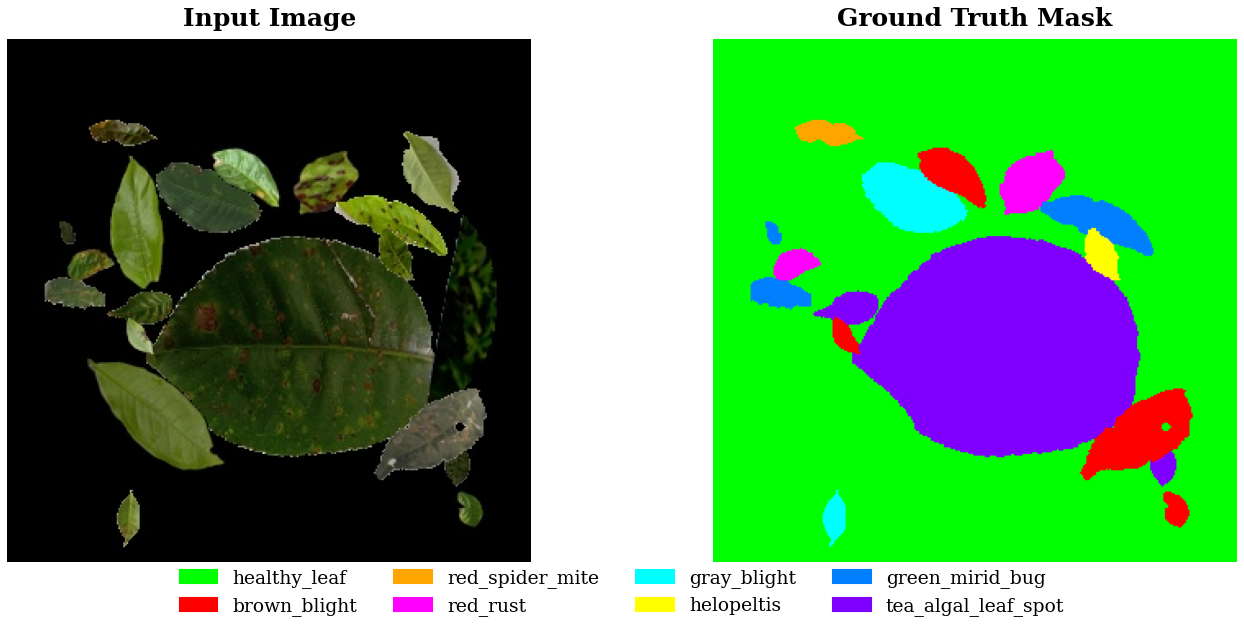

In [26]:
# --- Section 3: Data Loading (single sample) ------------------------------------

def load_single_sample(config):
    """Load a single validation image+mask for dissection."""
    _, val_loader, info = create_dataloaders(
        config["dataset"],
        image_size=config["image_size"],
        batch_size=1,
        num_workers=4,
        aug_intensity="light",
    )
    print(f"Dataset: {info.name}")
    print(f"  Classes:     {info.num_classes} ({info.type})")
    print(f"  Class names: {', '.join(info.class_names)}")
    print(f"  Input size:  {info.image_size}")
    print(f"  Val samples: {info.val_size:,}")

    # Grab one batch
    images, masks = next(iter(val_loader))
    print(f"\nSample image: {tuple(images.shape)}")
    print(f"Sample mask:  {tuple(masks.shape)}")
    print(f"Mask unique:  {masks.unique().tolist()}")
    return images, masks, info

sample_img, sample_mask, info = load_single_sample(CFG)

# Visualise the input
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Image (denormalised from ImageNet stats — denormalize returns (H, W, C) numpy)
img_np = denormalize(sample_img[0])
axes[0].imshow(img_np)
axes[0].set_title("Input Image", fontweight="bold")
axes[0].axis("off")

# Mask
mask_np = sample_mask[0].numpy()
colored = label_to_color(mask_np, info.palette)
axes[1].imshow(colored)
axes[1].set_title("Ground Truth Mask", fontweight="bold")
axes[1].axis("off")

# Legend
palette_01 = info.palette / 255.0
patches = [mpatches.Patch(color=palette_01[i], label=name)
           for i, name in enumerate(info.class_names)]
fig.legend(handles=patches, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

In [27]:
# --- Section 4: Model Loading ---------------------------------------------------

def build_and_load_model(info, config):
    """Build pro model and load best checkpoint."""
    model = umobilevit_pro(out_channels=info.num_classes, head="single")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model: U-MobileViT-Net [PRO]")
    print(f"  Parameters: {n_params:,} ({n_params / 1e6:.2f} M)")

    # Load checkpoint
    ckpt_path = config["checkpoint"]
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"  Checkpoint:  loaded (epoch {ckpt.get('epoch', '?')}, "
              f"val_miou={ckpt.get('val_metric', '?'):.4f})")
    else:
        print(f"  WARNING: checkpoint not found at {ckpt_path}, using random weights!")

    model = model.to(device)
    model.eval()

    # Smoke test
    with torch.no_grad():
        dummy = torch.randn(1, 3, *config["image_size"]).to(device)
        out = model(dummy)
        print(f"  Smoke test:  {tuple(dummy.shape)} -> {tuple(out.shape)}  PASSED")

    # NaN check
    nan_params = [n for n, p in model.named_parameters() if not torch.isfinite(p).all()]
    if nan_params:
        raise RuntimeError(f"{len(nan_params)} parameters contain NaN/Inf!")
    print("  Weight check: all parameters finite")

    return model, n_params

model, n_params = build_and_load_model(info, CFG)

# Print full model structure
print("\n" + "=" * 72)
print("MODEL STRUCTURE")
print("=" * 72)
print(model)

Model: U-MobileViT-Net [PRO]
  Parameters: 2,789,675 (2.79 M)
  Checkpoint:  loaded (epoch 300, val_miou=0.7033)
  Smoke test:  (1, 3, 320, 320) -> (1, 8, 320, 320)  PASSED
  Weight check: all parameters finite

MODEL STRUCTURE
UMobileViT(
  (encoder): UMobileViTEncoder(
    (stem_block): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): GroupNorm(4, 64, eps=1e-05, affine=True)
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): GroupNorm(4, 128, eps=1e-05, affine=True)
      )
    )
    (layers): ModuleList(
      (0): Sequential(
        (0): Sequential(
          (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), 

In [28]:
# --- Section 5: Hook Registration & Feature Extraction --------------------------

class FeatureExtractor:
    """Register forward hooks on named sub-modules and collect activations.

    Captures the output of every sub-layer we care about. Each activation is stored
    as a CPU tensor to avoid holding GPU memory.
    """
    def __init__(self, model: nn.Module):
        self.model = model
        self.activations: OrderedDict[str, torch.Tensor] = OrderedDict()
        self._handles = []

    def _hook_fn(self, name: str):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                self.activations[name] = output.detach().cpu()
            elif isinstance(output, (tuple, list)):
                # For modules returning multiple tensors, store first one
                for i, o in enumerate(output):
                    if isinstance(o, torch.Tensor):
                        self.activations[f"{name}[{i}]"] = o.detach().cpu()
        return hook

    def register_hooks(self):
        """Register hooks on all layers of interest."""
        model = self.model

        # ── Encoder: Stem blocks ──
        for i, stem_layer in enumerate(model.encoder.stem_block):
            stem_layer.register_forward_hook(
                self._hook_fn(f"encoder.stem[{i}]")
            )

        # ── Encoder: Stage layers (each has downsample + N encoder layers) ──
        for s_idx, stage in enumerate(model.encoder.layers):
            stage_num = s_idx + 1
            # Downsample block
            stage[0].register_forward_hook(
                self._hook_fn(f"encoder.stage{stage_num}.downsample")
            )
            # Encoder layers
            for l_idx, enc_layer in enumerate(stage[1:], start=1):
                layer_name = f"encoder.stage{stage_num}.layer{l_idx}"
                enc_layer.register_forward_hook(
                    self._hook_fn(f"{layer_name}.output")
                )
                # Sub-blocks within each encoder layer
                enc_layer.local_block.register_forward_hook(
                    self._hook_fn(f"{layer_name}.local")
                )
                # Hook first transformer block (ModuleList items called individually)
                if len(enc_layer.global_block) > 0:
                    enc_layer.global_block[0].register_forward_hook(
                        self._hook_fn(f"{layer_name}.global.t0")
                    )
                enc_layer.expansion_block.register_forward_hook(
                    self._hook_fn(f"{layer_name}.expansion")
                )

        # ── Decoder: Stage layers (each has upsample + N decoder layers) ──
        dec_stage_names = ["decoder.stage1", "decoder.stage2", "decoder.out"]
        for s_idx, stage in enumerate(model.decoder.layers):
            stage_name = dec_stage_names[s_idx]
            # Upsample block
            stage[0].register_forward_hook(
                self._hook_fn(f"{stage_name}.upsample")
            )
            # Decoder layers
            for l_idx, dec_layer in enumerate(stage[1:], start=1):
                layer_name = f"{stage_name}.layer{l_idx}"
                dec_layer.register_forward_hook(
                    self._hook_fn(f"{layer_name}.output")
                )
                # Sub-blocks
                dec_layer.local_block.register_forward_hook(
                    self._hook_fn(f"{layer_name}.local")
                )
                # Hook global block: ConcatLayer has Sequential (fires directly),
                # other layers have ModuleList (hook first transformer block)
                if hasattr(dec_layer, 'global_block') and len(dec_layer.global_block) > 0:
                    gb = dec_layer.global_block
                    if isinstance(gb, nn.ModuleList):  # ModuleList — hook first item
                        gb[0].register_forward_hook(
                            self._hook_fn(f"{layer_name}.global.t0"))
                    else:  # Sequential (ConcatLayer) — hook directly
                        gb.register_forward_hook(
                            self._hook_fn(f"{layer_name}.global"))
                dec_layer.expansion_block.register_forward_hook(
                    self._hook_fn(f"{layer_name}.expansion")
                )

        # ── SegHead: Upsample stages ──
        seg_head = model.seg_head
        if hasattr(seg_head, 'upsample_module'):
            upsample = seg_head.upsample_module
            for i, stage in enumerate(upsample.layers):
                # Sequential [conv1x1 + upsample_conv]
                stage[0].register_forward_hook(
                    self._hook_fn(f"seg_head.upsample_x{2**(i+1)}")
                )
                # ConcatLayer (if present)
                for j, sub in enumerate(stage[1:], start=1):
                    sub.register_forward_hook(
                        self._hook_fn(f"seg_head.upsample_x{2**(i+1)}.concat{j}")
                    )

        # ── SegHead: Refinement ──
        if hasattr(seg_head, 'refinement_module'):
            seg_head.refinement_module.register_forward_hook(
                self._hook_fn("seg_head.refinement")
            )

        # ── Final Classifier ──
        if hasattr(seg_head, 'classifier'):
            seg_head.classifier.register_forward_hook(
                self._hook_fn("seg_head.classifier")
            )
        elif hasattr(seg_head, 'task_classifiers'):
            for i, clf in enumerate(seg_head.task_classifiers):
                clf.register_forward_hook(
                    self._hook_fn(f"seg_head.classifier_task{i}")
                )

    def extract(self, image: torch.Tensor) -> OrderedDict:
        """Run one forward pass and return all captured activations."""
        self.activations.clear()
        with torch.no_grad():
            self.model(image)
        return self.activations

    def remove_hooks(self):
        for handle in self._handles:
            handle.remove()
        self._handles.clear()


# Instantiate extractor and register hooks
extractor = FeatureExtractor(model)
extractor.register_hooks()

# Run inference on the sample image
img_gpu = sample_img.to(device)
activations = extractor.extract(img_gpu)

print(f"Captured {len(activations)} activation maps:")
for name, tensor in activations.items():
    print(f"  {name:<50s}  shape={tuple(tensor.shape)}")

Captured 52 activation maps:
  encoder.stem[0]                                     shape=(1, 32, 160, 160)
  encoder.stem[1]                                     shape=(1, 64, 80, 80)
  encoder.stem[2]                                     shape=(1, 128, 40, 40)
  encoder.stage1.downsample                           shape=(1, 128, 20, 20)
  encoder.stage1.layer1.local                         shape=(1, 128, 20, 20)
  encoder.stage1.layer1.global.t0                     shape=(1, 128, 4, 100)
  encoder.stage1.layer1.expansion                     shape=(1, 128, 20, 20)
  encoder.stage1.layer1.output                        shape=(1, 128, 20, 20)
  encoder.stage2.downsample                           shape=(1, 128, 10, 10)
  encoder.stage2.layer1.local                         shape=(1, 128, 10, 10)
  encoder.stage2.layer1.global.t0                     shape=(1, 128, 4, 25)
  encoder.stage2.layer1.expansion                     shape=(1, 128, 10, 10)
  encoder.stage2.layer1.output                  

In [29]:
# --- Section 6: Heatmap Visualisation Utilities ---------------------------------

def activation_heatmap(
    tensor: torch.Tensor,           # (1, C, H, W)
    ax: plt.Axes,
    title: str = "",
    cmap: str = "inferno",
    show_colorbar: bool = True,
    percentile_clip: float = 98.0,  # clip top percentile for better contrast
):
    """Plot channel-averaged activation as a 2D heatmap.

    Averages across the channel dimension to produce a single spatial map
    showing where the layer is most active.
    """
    assert tensor.dim() == 4, f"Expected 4D tensor (1,C,H,W), got {tensor.dim()}D"
    feat = tensor[0]                    # (C, H, W)
    amap = feat.abs().mean(dim=0)        # (H, W) — mean absolute activation

    # Clip outliers for better contrast
    vmax = np.percentile(amap.numpy(), percentile_clip)
    vmin = amap.min().item()

    im = ax.imshow(amap.numpy(), cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.axis("off")
    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def channel_heatmap_grid(
    tensor: torch.Tensor,           # (1, C, H, W)
    n_cols: int = 8,
    title: str = "",
    cmap: str = "inferno",
    figsize_scale: float = 1.5,
):
    """Plot first K channels as individual heatmaps in a grid.

    Useful for seeing what individual filters have learned.
    """
    C = tensor.shape[1]
    n_show = min(C, 32)  # show at most 32 channels
    n_rows = int(np.ceil(n_show / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_scale, n_rows * figsize_scale))
    axes = axes.flatten() if n_rows > 1 else ([axes] if n_cols == 1 else axes)

    for c in range(n_show):
        amap = tensor[0, c].numpy()
        vmax = np.percentile(amap, 98)
        im = axes[c].imshow(amap, cmap=cmap, norm=Normalize(vmin=amap.min(), vmax=vmax))
        axes[c].set_title(f"ch {c}", fontsize=7)
        axes[c].axis("off")

    for c in range(n_show, len(axes)):
        axes[c].axis("off")

    fig.suptitle(title, fontweight="bold", fontsize=11, y=1.01)
    plt.tight_layout()
    return fig


def plot_activation_summary(
    activations: OrderedDict,
    keys: List[str],
    title: str,
    n_cols: int = 4,
    figsize_per_row: float = 3.5,
):
    """Plot channel-mean heatmaps for a list of activation keys in a grid."""
    valid_keys = [k for k in keys if k in activations]
    if not valid_keys:
        print(f"  (none found for {title})")
        return

    n_rows = int(np.ceil(len(valid_keys) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * figsize_per_row, n_rows * figsize_per_row))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, key in enumerate(valid_keys):
        activation_heatmap(activations[key], axes[i], title=key, show_colorbar=(i == 0))
    for j in range(len(valid_keys), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontweight="bold", fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


def plot_side_by_side_heatmaps(
    activations: OrderedDict,
    key_pairs: List[Tuple[str, str, str]],  # (key, label, description)
    suptitle: str = "",
    n_cols: int = 2,
    figsize_per_cell: float = 3.5,
):
    """Plot selected activation heatmaps side by side with descriptive labels."""
    valid = [(k, lbl, desc) for k, lbl, desc in key_pairs if k in activations]
    if not valid:
        print(f"  (none found)")
        return

    n_rows = int(np.ceil(len(valid) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * figsize_per_cell, n_rows * figsize_per_cell))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (key, label, desc) in enumerate(valid):
        tensor = activations[key]
        title = f"{label}\n{desc}  [{tuple(tensor.shape[1:])}]"
        activation_heatmap(tensor, axes[i], title=title, show_colorbar=(i == 0))
    for j in range(len(valid), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontweight="bold", fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


print("Utility functions defined:")
print("  - activation_heatmap()        single channel-mean heatmap")
print("  - channel_heatmap_grid()      per-channel grid (first 32 ch)")
print("  - plot_activation_summary()   multi-key grid")
print("  - plot_side_by_side_heatmaps() labelled comparison grid")

Utility functions defined:
  - activation_heatmap()        single channel-mean heatmap
  - channel_heatmap_grid()      per-channel grid (first 32 ch)
  - plot_activation_summary()   multi-key grid
  - plot_side_by_side_heatmaps() labelled comparison grid


---
## 6A. Encoder Stem — Early Visual Features

The stem is three Conv3×3+ReLU blocks with stride 2, reducing spatial resolution  
from 320→160→80→40 while expanding channels 3→32→64→128.  
These capture low-level features: edges, textures, colour blobs.

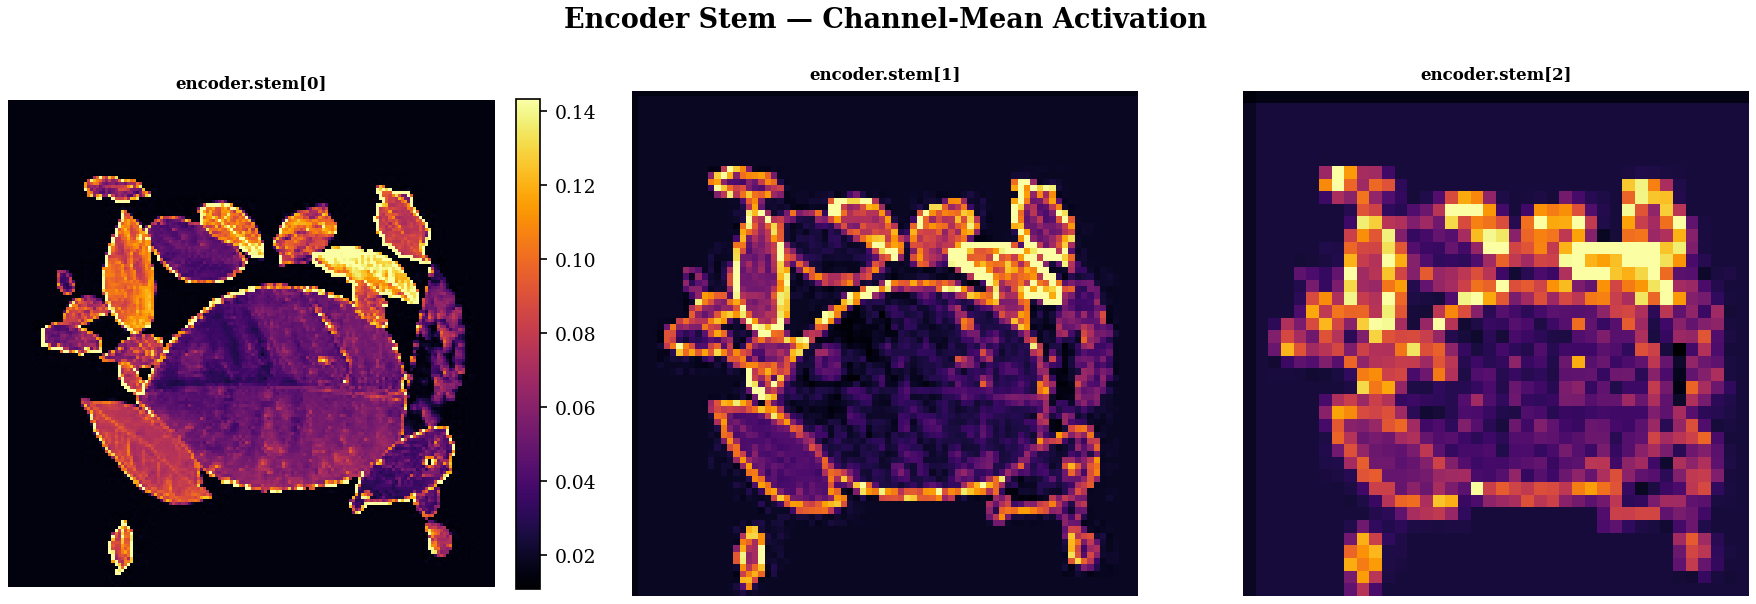

In [30]:
# ── Stem heatmaps: channel-mean ──
stem_keys = [
    "encoder.stem[0]",   #  32ch, 160×160
    "encoder.stem[1]",   #  64ch,  80×80
    "encoder.stem[2]",   # 128ch,  40×40
]

plot_activation_summary(activations, stem_keys,
                        title="Encoder Stem — Channel-Mean Activation",
                        n_cols=3, figsize_per_row=4.0)
plt.show()

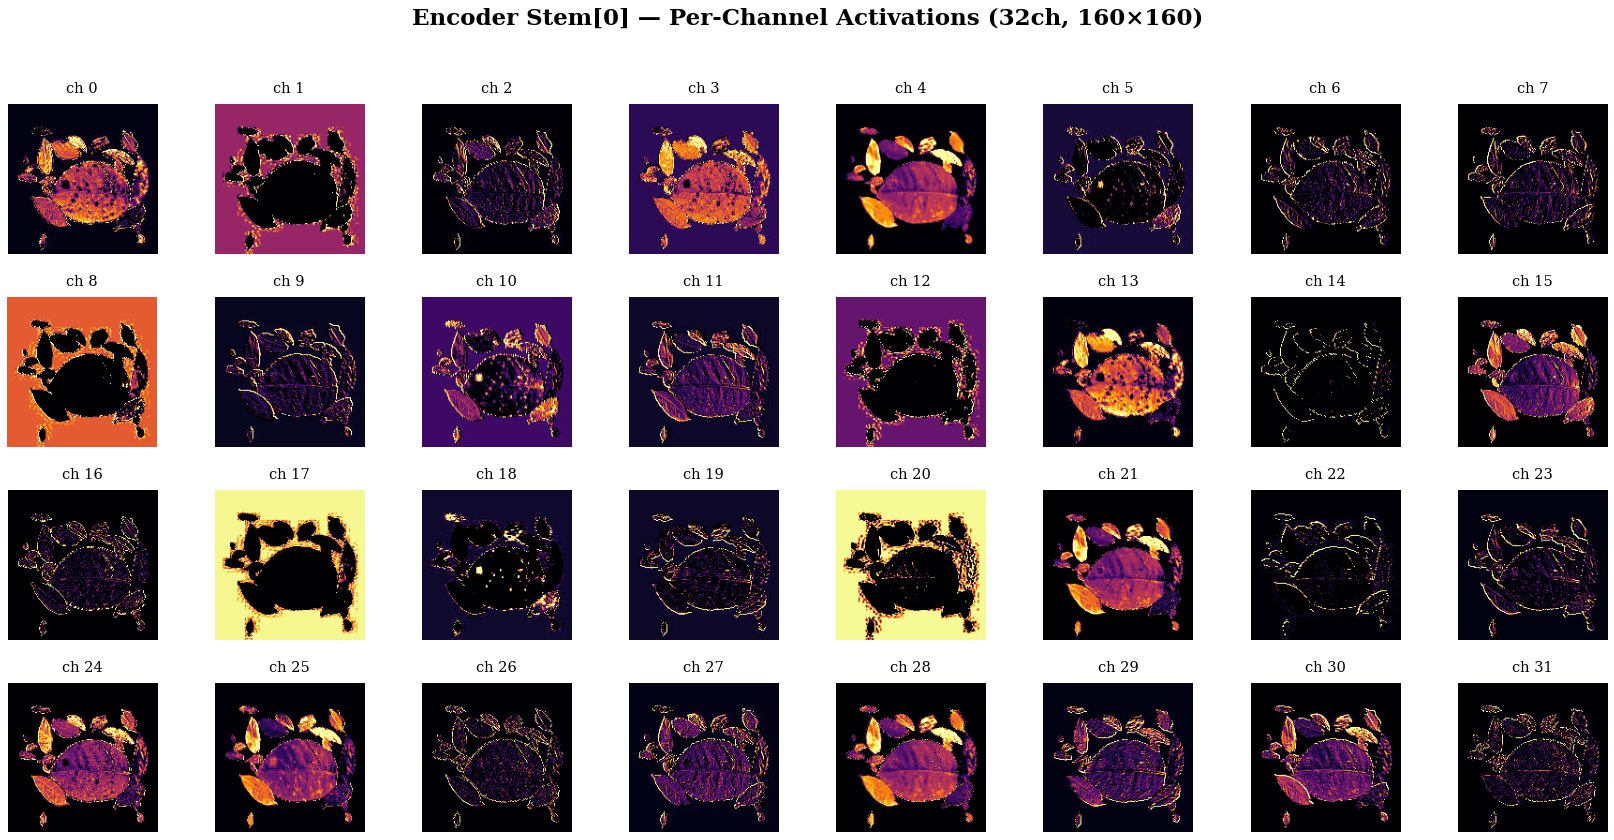

In [31]:
# ── Stem: Per-channel grids for stem[0] (32 channels, closest to input) ──
fig = channel_heatmap_grid(
    activations["encoder.stem[0]"],
    n_cols=8,
    title="Encoder Stem[0] — Per-Channel Activations (32ch, 160×160)",
    figsize_scale=1.4,
)
plt.show()

---
## 6B. Encoder Stage 1 — First Transformer Stage

**Stage 1**: Depthwise Conv3×3 s2 (128ch, 40→20) + 1× `UMobileViTEncoderLayer`  
Each encoder layer decomposes into: **local** → **global** (self-attention) → **expansion** (inverted bottleneck) → **out_norm** (residual).  
Resolution: 20×20, Channels: 128

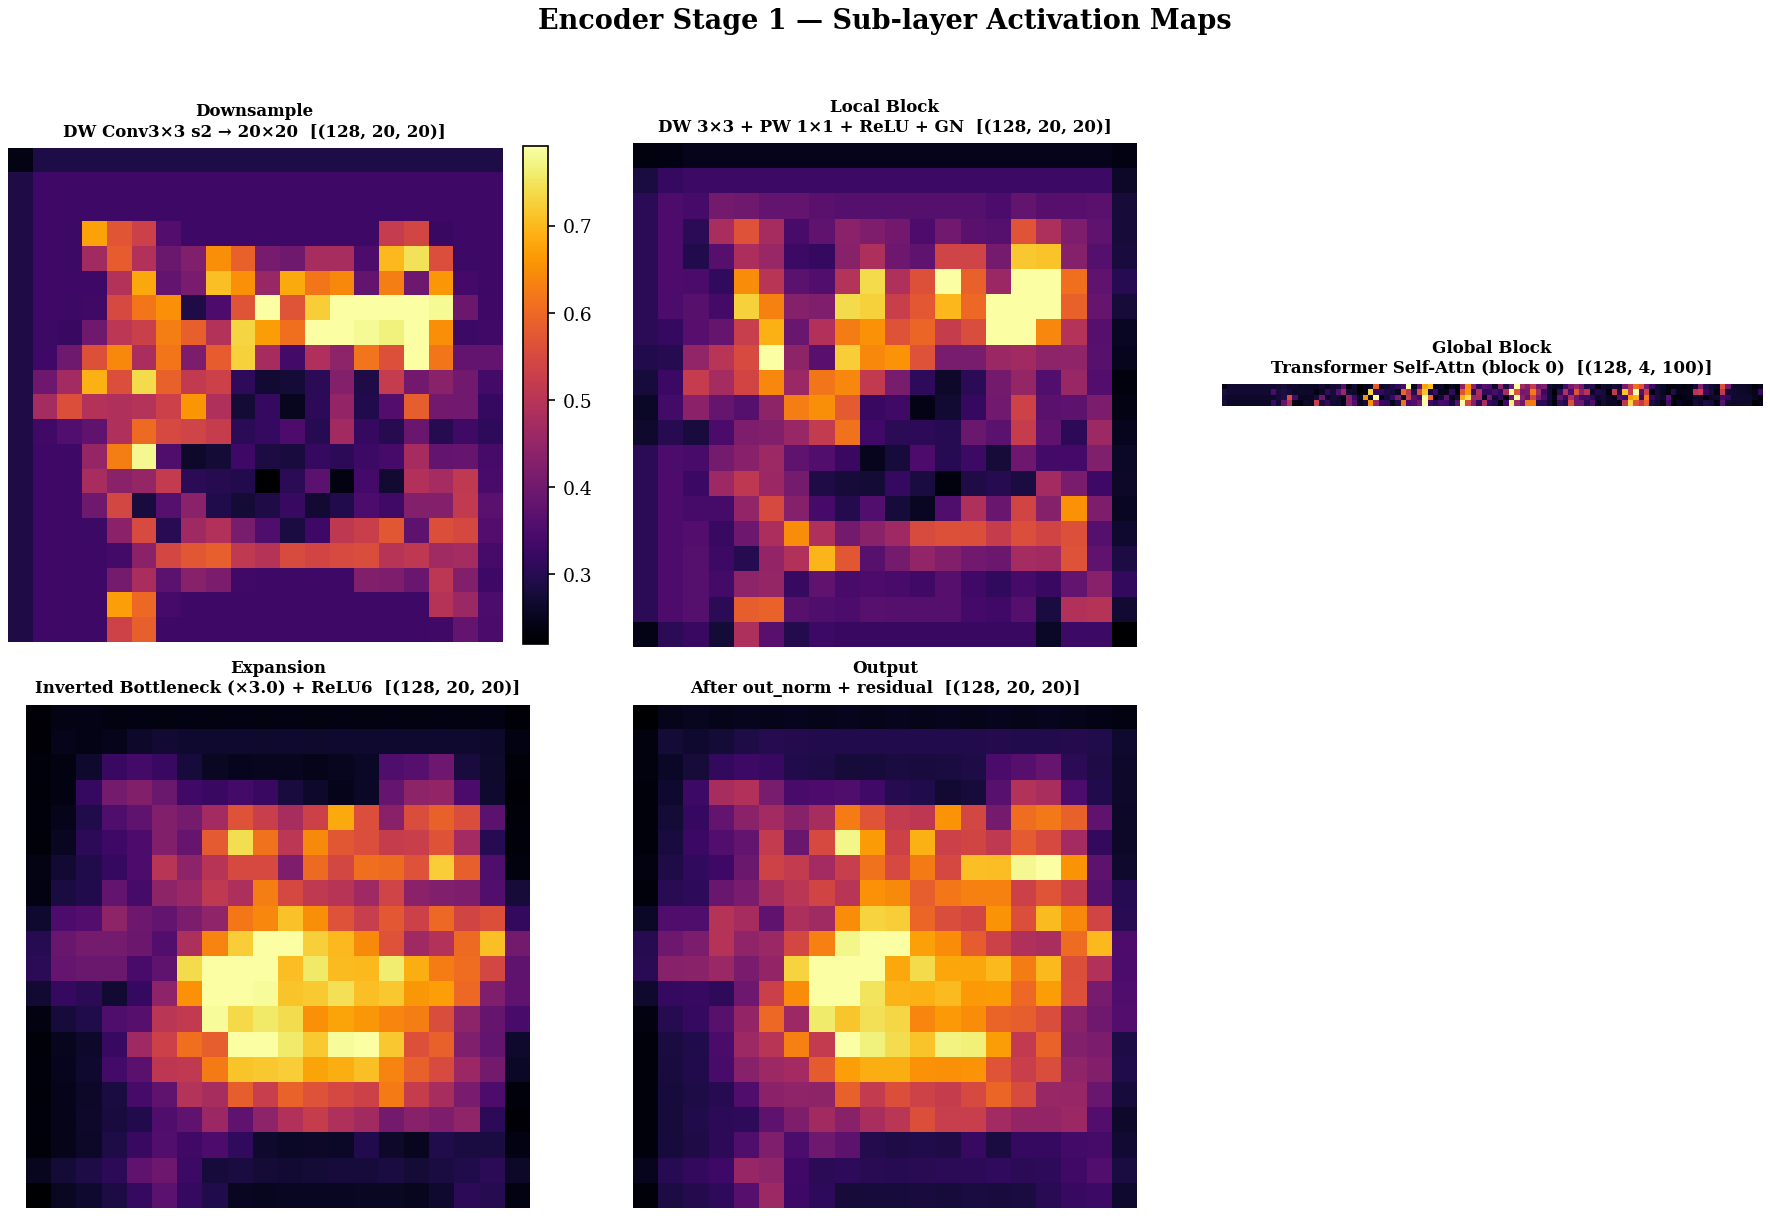

In [32]:
# ── Encoder Stage 1: Sub-layer breakdown ──
enc1_sub_keys = [
    ("encoder.stage1.downsample",   "Downsample",  "DW Conv3×3 s2 → 20×20"),
    ("encoder.stage1.layer1.local",  "Local Block",  "DW 3×3 + PW 1×1 + ReLU + GN"),
    ("encoder.stage1.layer1.global.t0", "Global Block",  "Transformer Self-Attn (block 0)"),
    ("encoder.stage1.layer1.expansion", "Expansion",  "Inverted Bottleneck (×3.0) + ReLU6"),
    ("encoder.stage1.layer1.output", "Output",       "After out_norm + residual"),
]

plot_side_by_side_heatmaps(
    activations, enc1_sub_keys,
    suptitle="Encoder Stage 1 — Sub-layer Activation Maps",
    n_cols=3, figsize_per_cell=4.0,
)
plt.show()

---
## 6C. Encoder Stage 2 — Deeper Features

**Stage 2**: DW Conv3×3 s2 (20→10) + 2× `UMobileViTEncoderLayer`  
Resolution: 10×10, Channels: 128

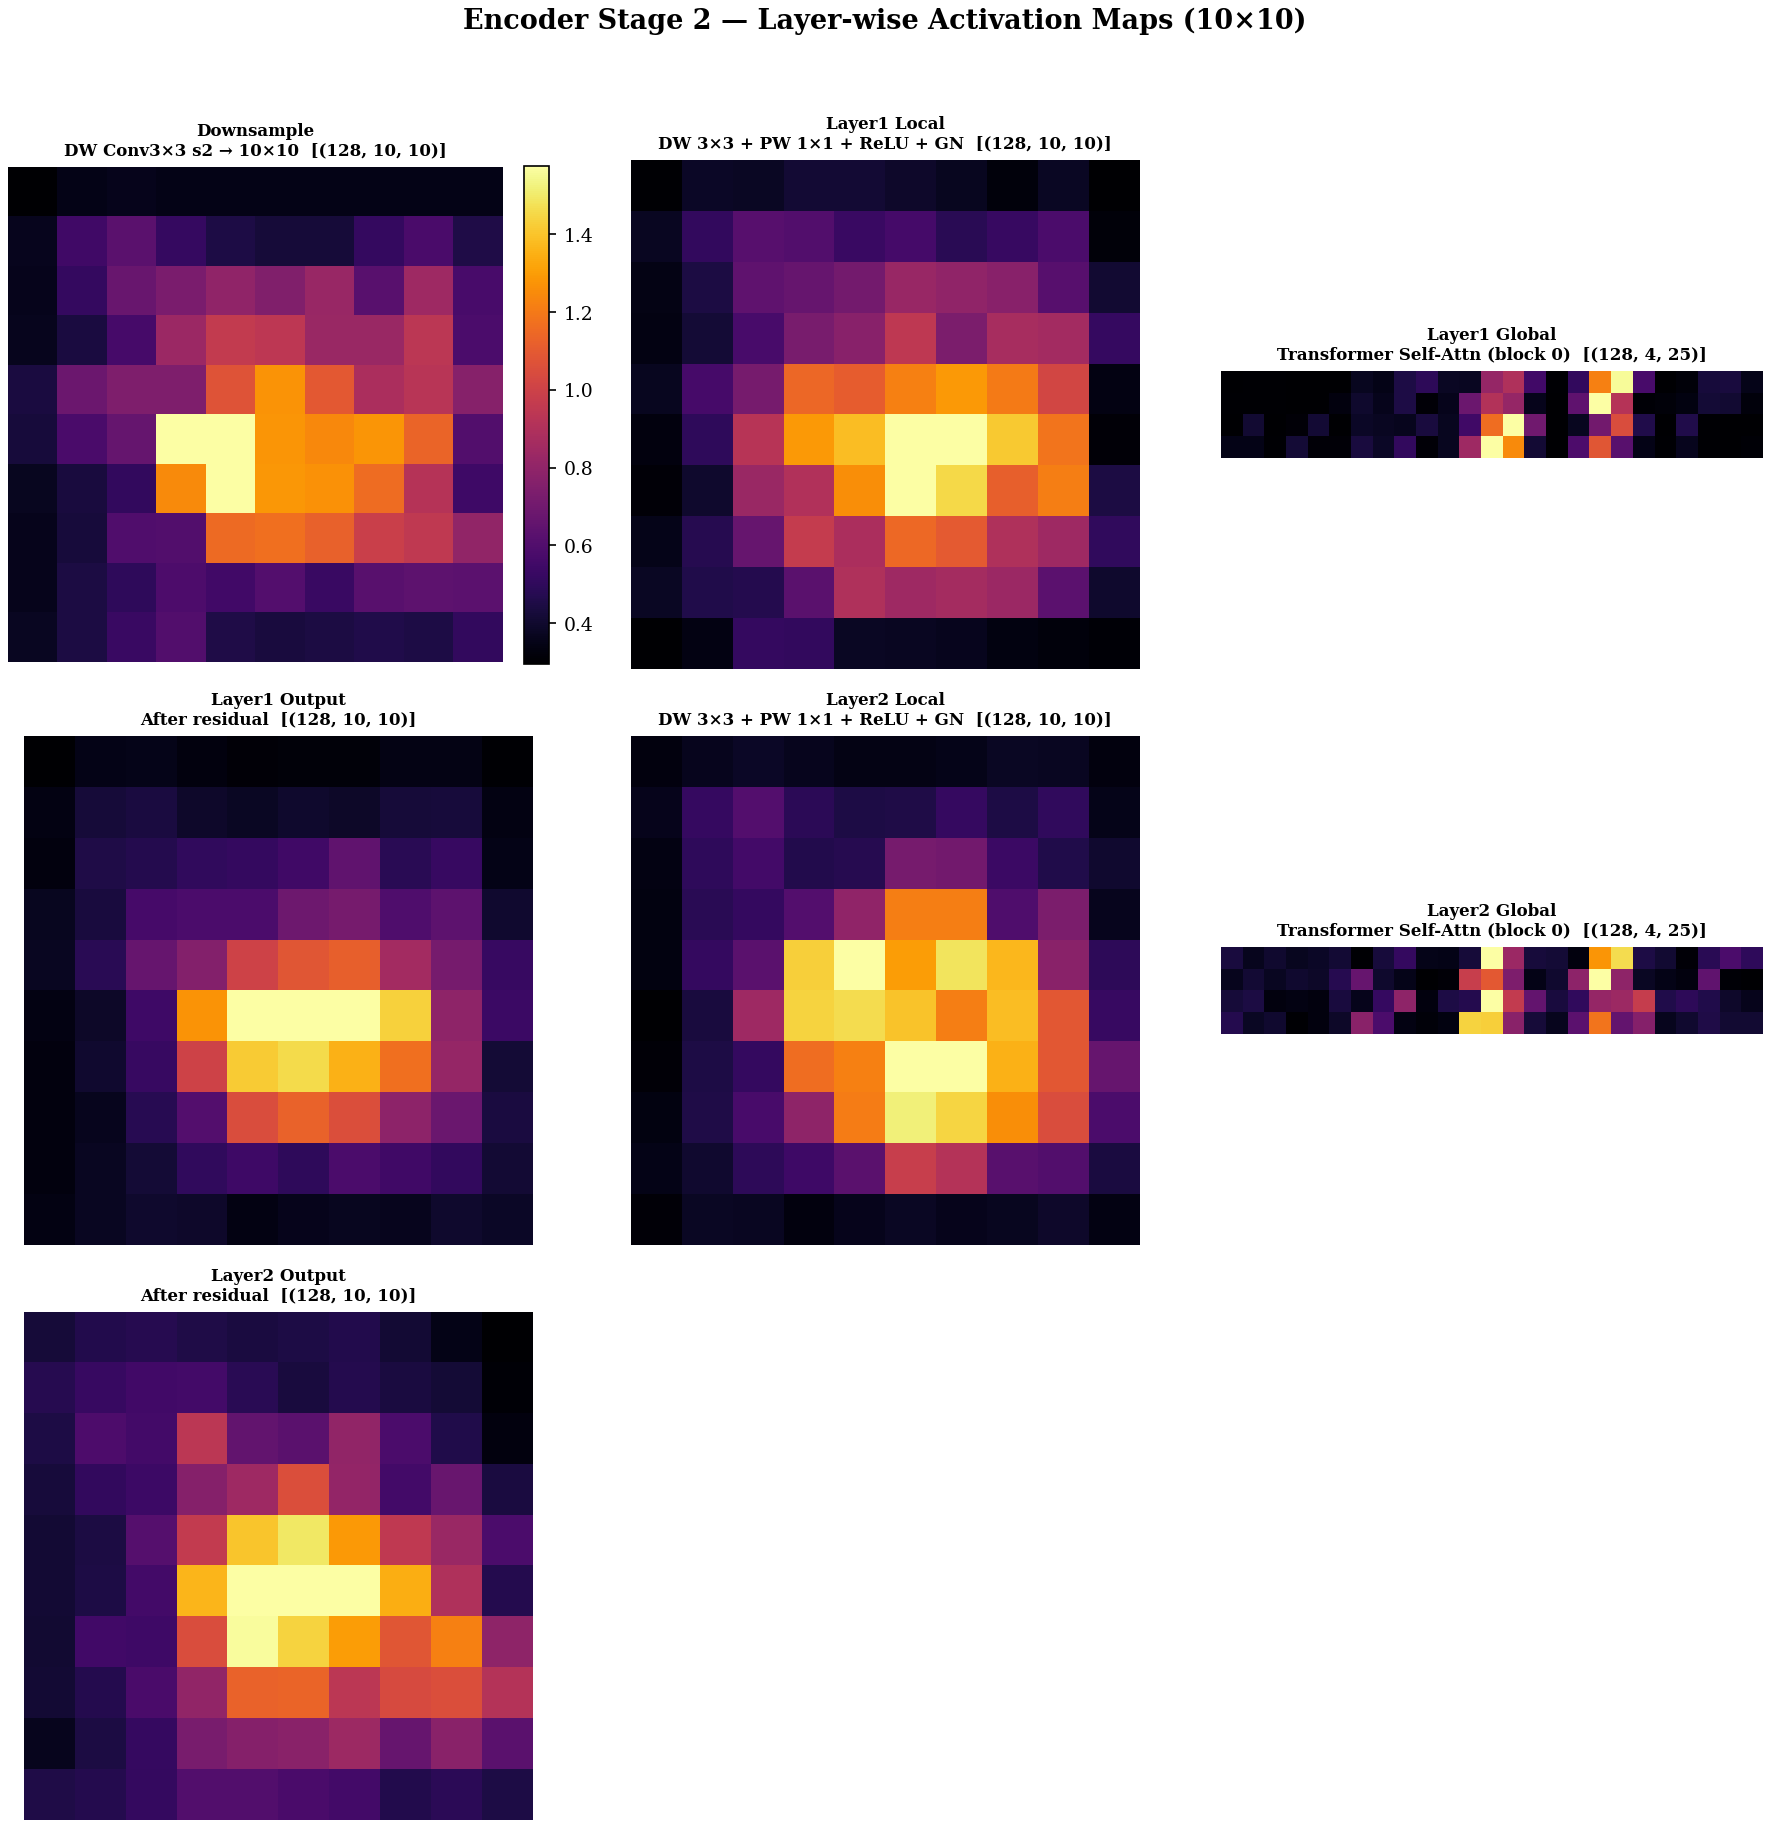

In [33]:
# ── Encoder Stage 2: Output of each layer ──
enc2_keys = [
    ("encoder.stage2.downsample",    "Downsample",   "DW Conv3×3 s2 → 10×10"),
    ("encoder.stage2.layer1.local",   "Layer1 Local",  "DW 3×3 + PW 1×1 + ReLU + GN"),
    ("encoder.stage2.layer1.global.t0",  "Layer1 Global", "Transformer Self-Attn (block 0)"),
    ("encoder.stage2.layer1.output",  "Layer1 Output", "After residual"),
    ("encoder.stage2.layer2.local",   "Layer2 Local",  "DW 3×3 + PW 1×1 + ReLU + GN"),
    ("encoder.stage2.layer2.global.t0",  "Layer2 Global", "Transformer Self-Attn (block 0)"),
    ("encoder.stage2.layer2.output",  "Layer2 Output", "After residual"),
]

plot_side_by_side_heatmaps(
    activations, enc2_keys,
    suptitle="Encoder Stage 2 — Layer-wise Activation Maps (10×10)",
    n_cols=3, figsize_per_cell=4.0,
)
plt.show()

---
## 6D. Encoder Stage 3 — Bottleneck (no unfolding)

**Stage 3**: DW Conv3×3 s2 (10→5) + 2× `UMobileViTEncoderLayer` with `patch_size=(1,1)`  
At 5×5 resolution with patch_size=1, the transformer operates directly on each spatial  
position without unfolding — acting as a global context aggregator.  
Resolution: 5×5, Channels: 128

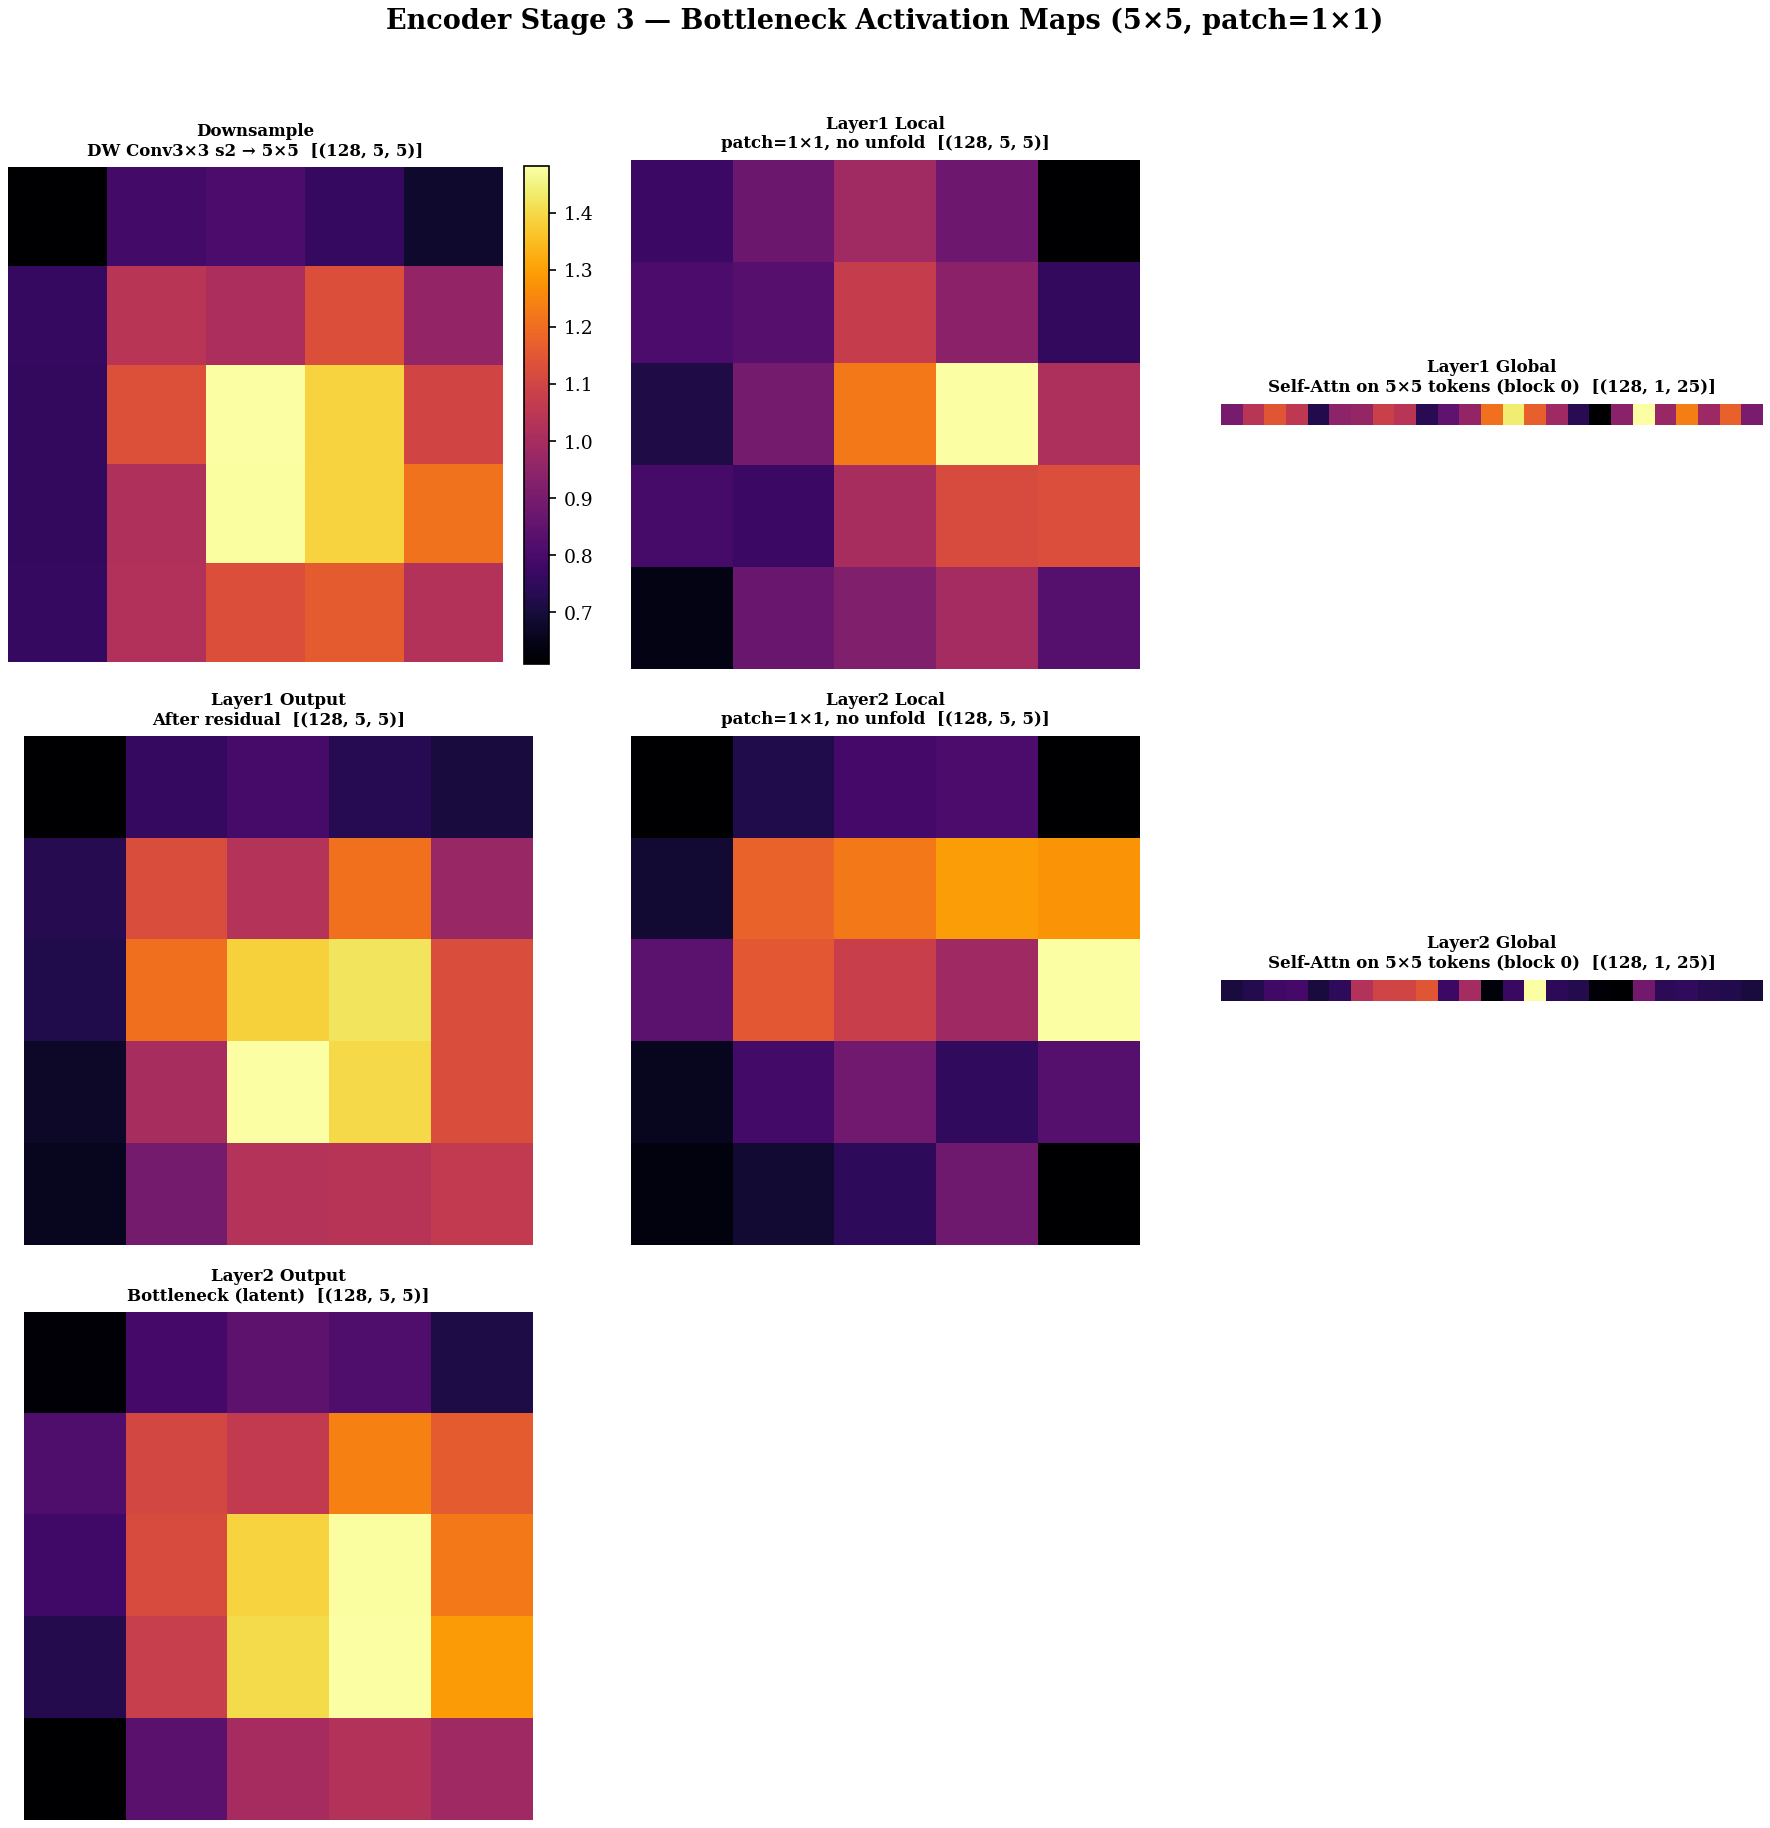

In [34]:
# ── Encoder Stage 3: Bottleneck features ──
enc3_keys = [
    ("encoder.stage3.downsample",    "Downsample",   "DW Conv3×3 s2 → 5×5"),
    ("encoder.stage3.layer1.local",   "Layer1 Local",  "patch=1×1, no unfold"),
    ("encoder.stage3.layer1.global.t0",  "Layer1 Global", "Self-Attn on 5×5 tokens (block 0)"),
    ("encoder.stage3.layer1.output",  "Layer1 Output", "After residual"),
    ("encoder.stage3.layer2.local",   "Layer2 Local",  "patch=1×1, no unfold"),
    ("encoder.stage3.layer2.global.t0",  "Layer2 Global", "Self-Attn on 5×5 tokens (block 0)"),
    ("encoder.stage3.layer2.output",  "Layer2 Output", "Bottleneck (latent)"),
]

plot_side_by_side_heatmaps(
    activations, enc3_keys,
    suptitle="Encoder Stage 3 — Bottleneck Activation Maps (5×5, patch=1×1)",
    n_cols=3, figsize_per_cell=4.0,
)
plt.show()

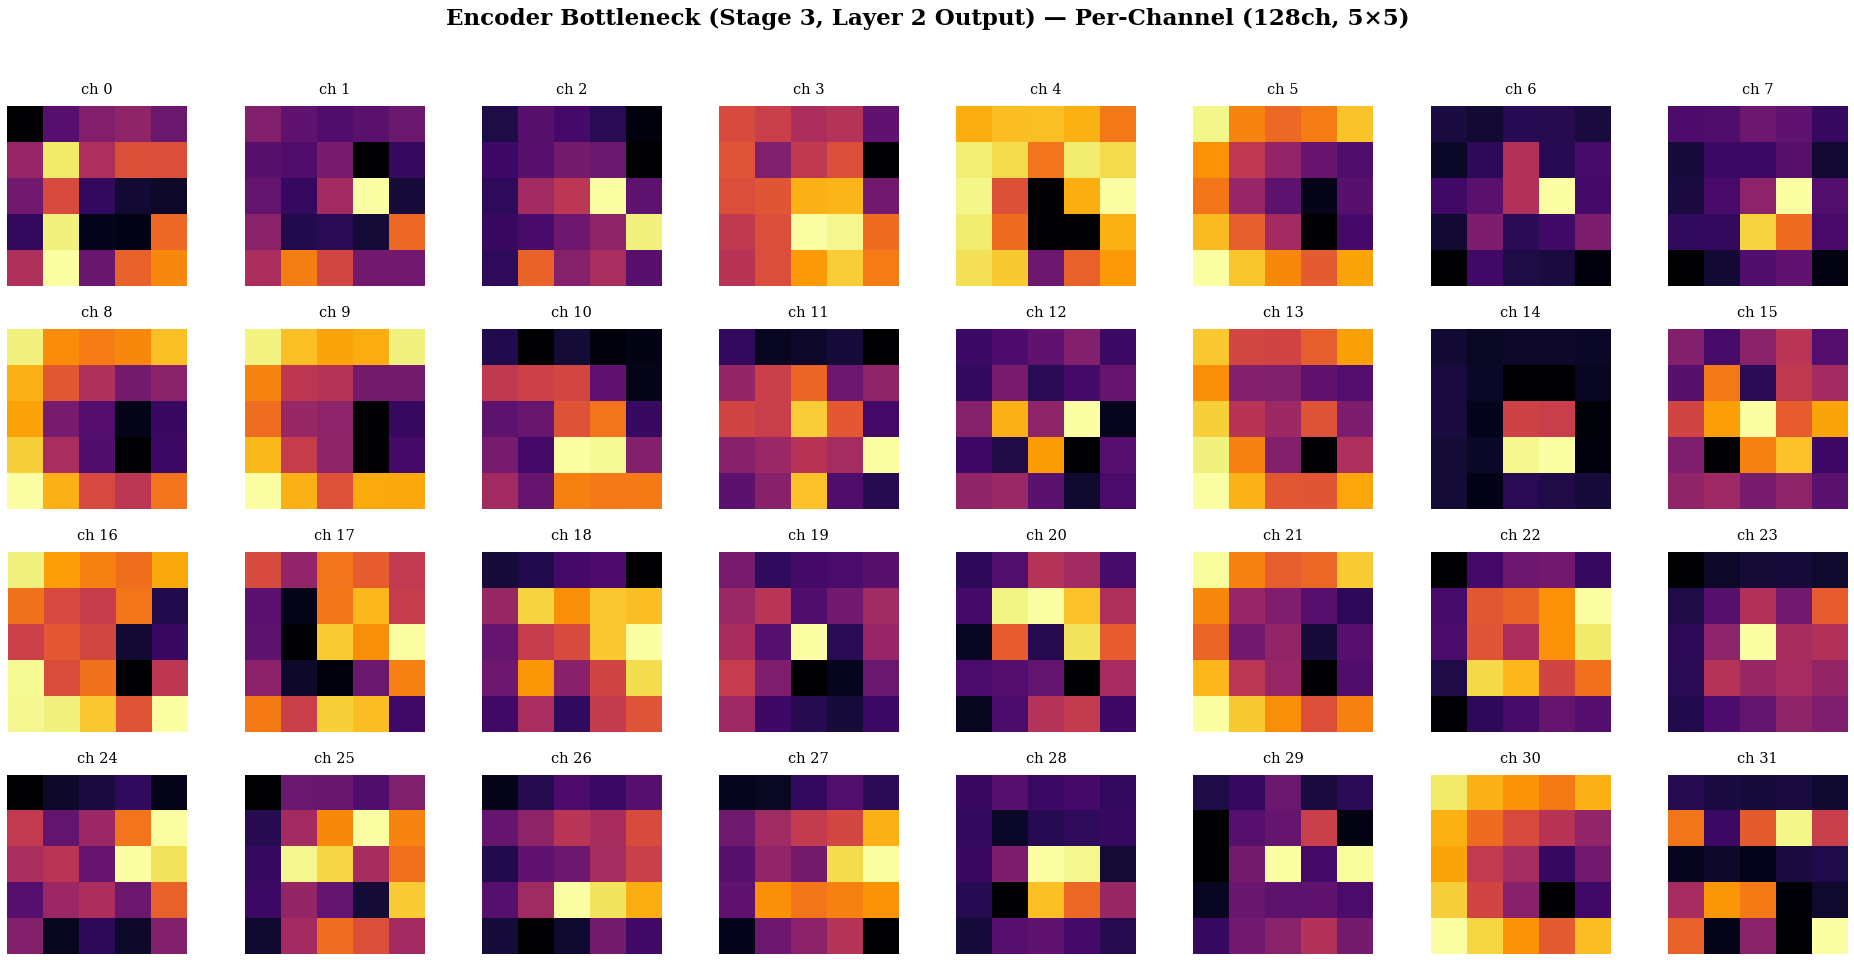

In [35]:
# ── Encoder Stage 3: Per-channel grid (bottleneck — only 5×5 but 128 channels) ──
fig = channel_heatmap_grid(
    activations["encoder.stage3.layer2.output"],
    n_cols=8,
    title="Encoder Bottleneck (Stage 3, Layer 2 Output) — Per-Channel (128ch, 5×5)",
    figsize_scale=1.6,
)
plt.show()

---
## 6E. Encoder — Cross-Stage Comparison

How do features evolve across encoder stages? Compare the output of each stage.

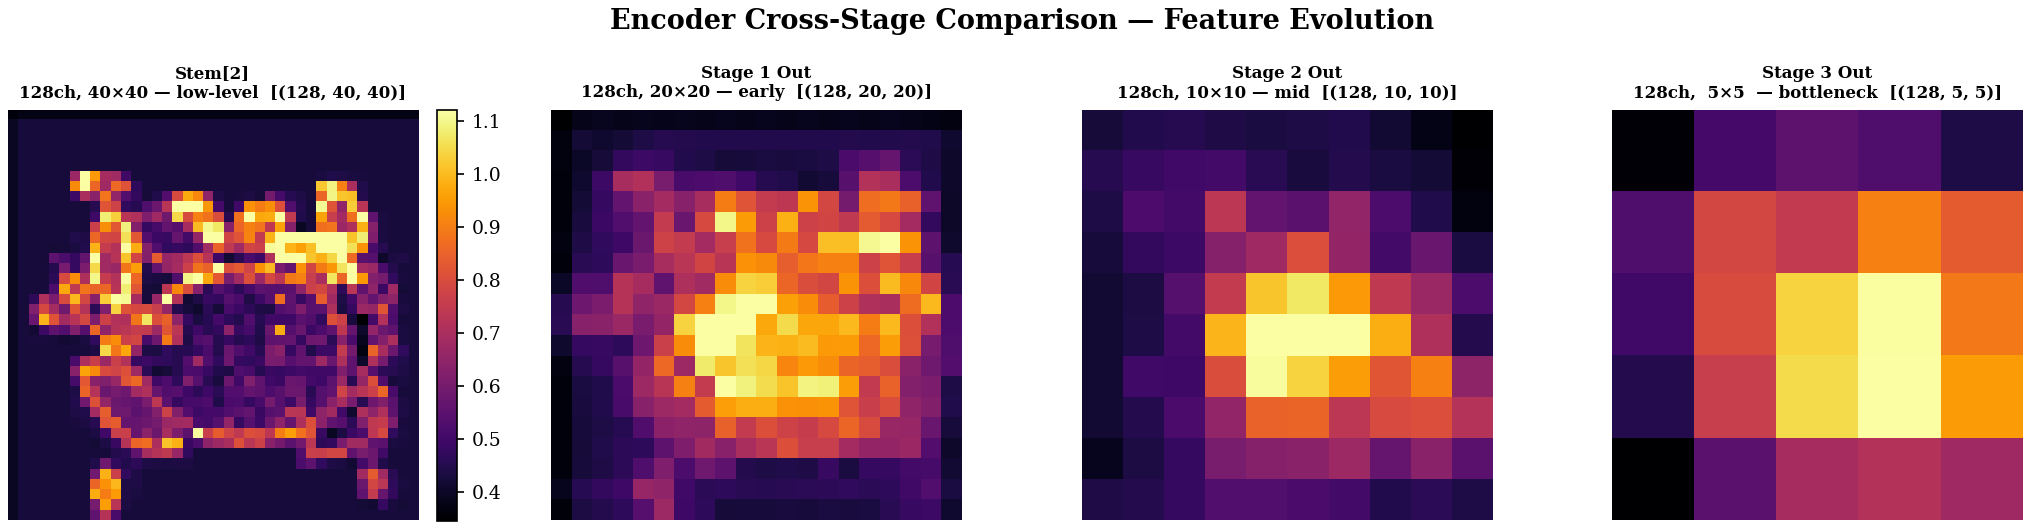

In [36]:
# Cross-stage comparison: final output of each encoder stage
cross_stage_keys = [
    ("encoder.stem[2]",                 "Stem[2]",       "128ch, 40×40 — low-level"),
    ("encoder.stage1.layer1.output",    "Stage 1 Out",   "128ch, 20×20 — early"),
    ("encoder.stage2.layer2.output",    "Stage 2 Out",   "128ch, 10×10 — mid"),
    ("encoder.stage3.layer2.output",    "Stage 3 Out",   "128ch,  5×5  — bottleneck"),
]

plot_side_by_side_heatmaps(
    activations, cross_stage_keys,
    suptitle="Encoder Cross-Stage Comparison — Feature Evolution",
    n_cols=4, figsize_per_cell=3.5,
)
plt.show()

---
## 7A. Decoder Stage 1 — First Upsampling + Cross-Attention

**Stage 1**: Upsample ×2 (5→10) + 2× `UMobileViTDecoderLayer` (cross-attention with encoder Stage 2 skip)  
Resolution: 10×10, Channels: 128

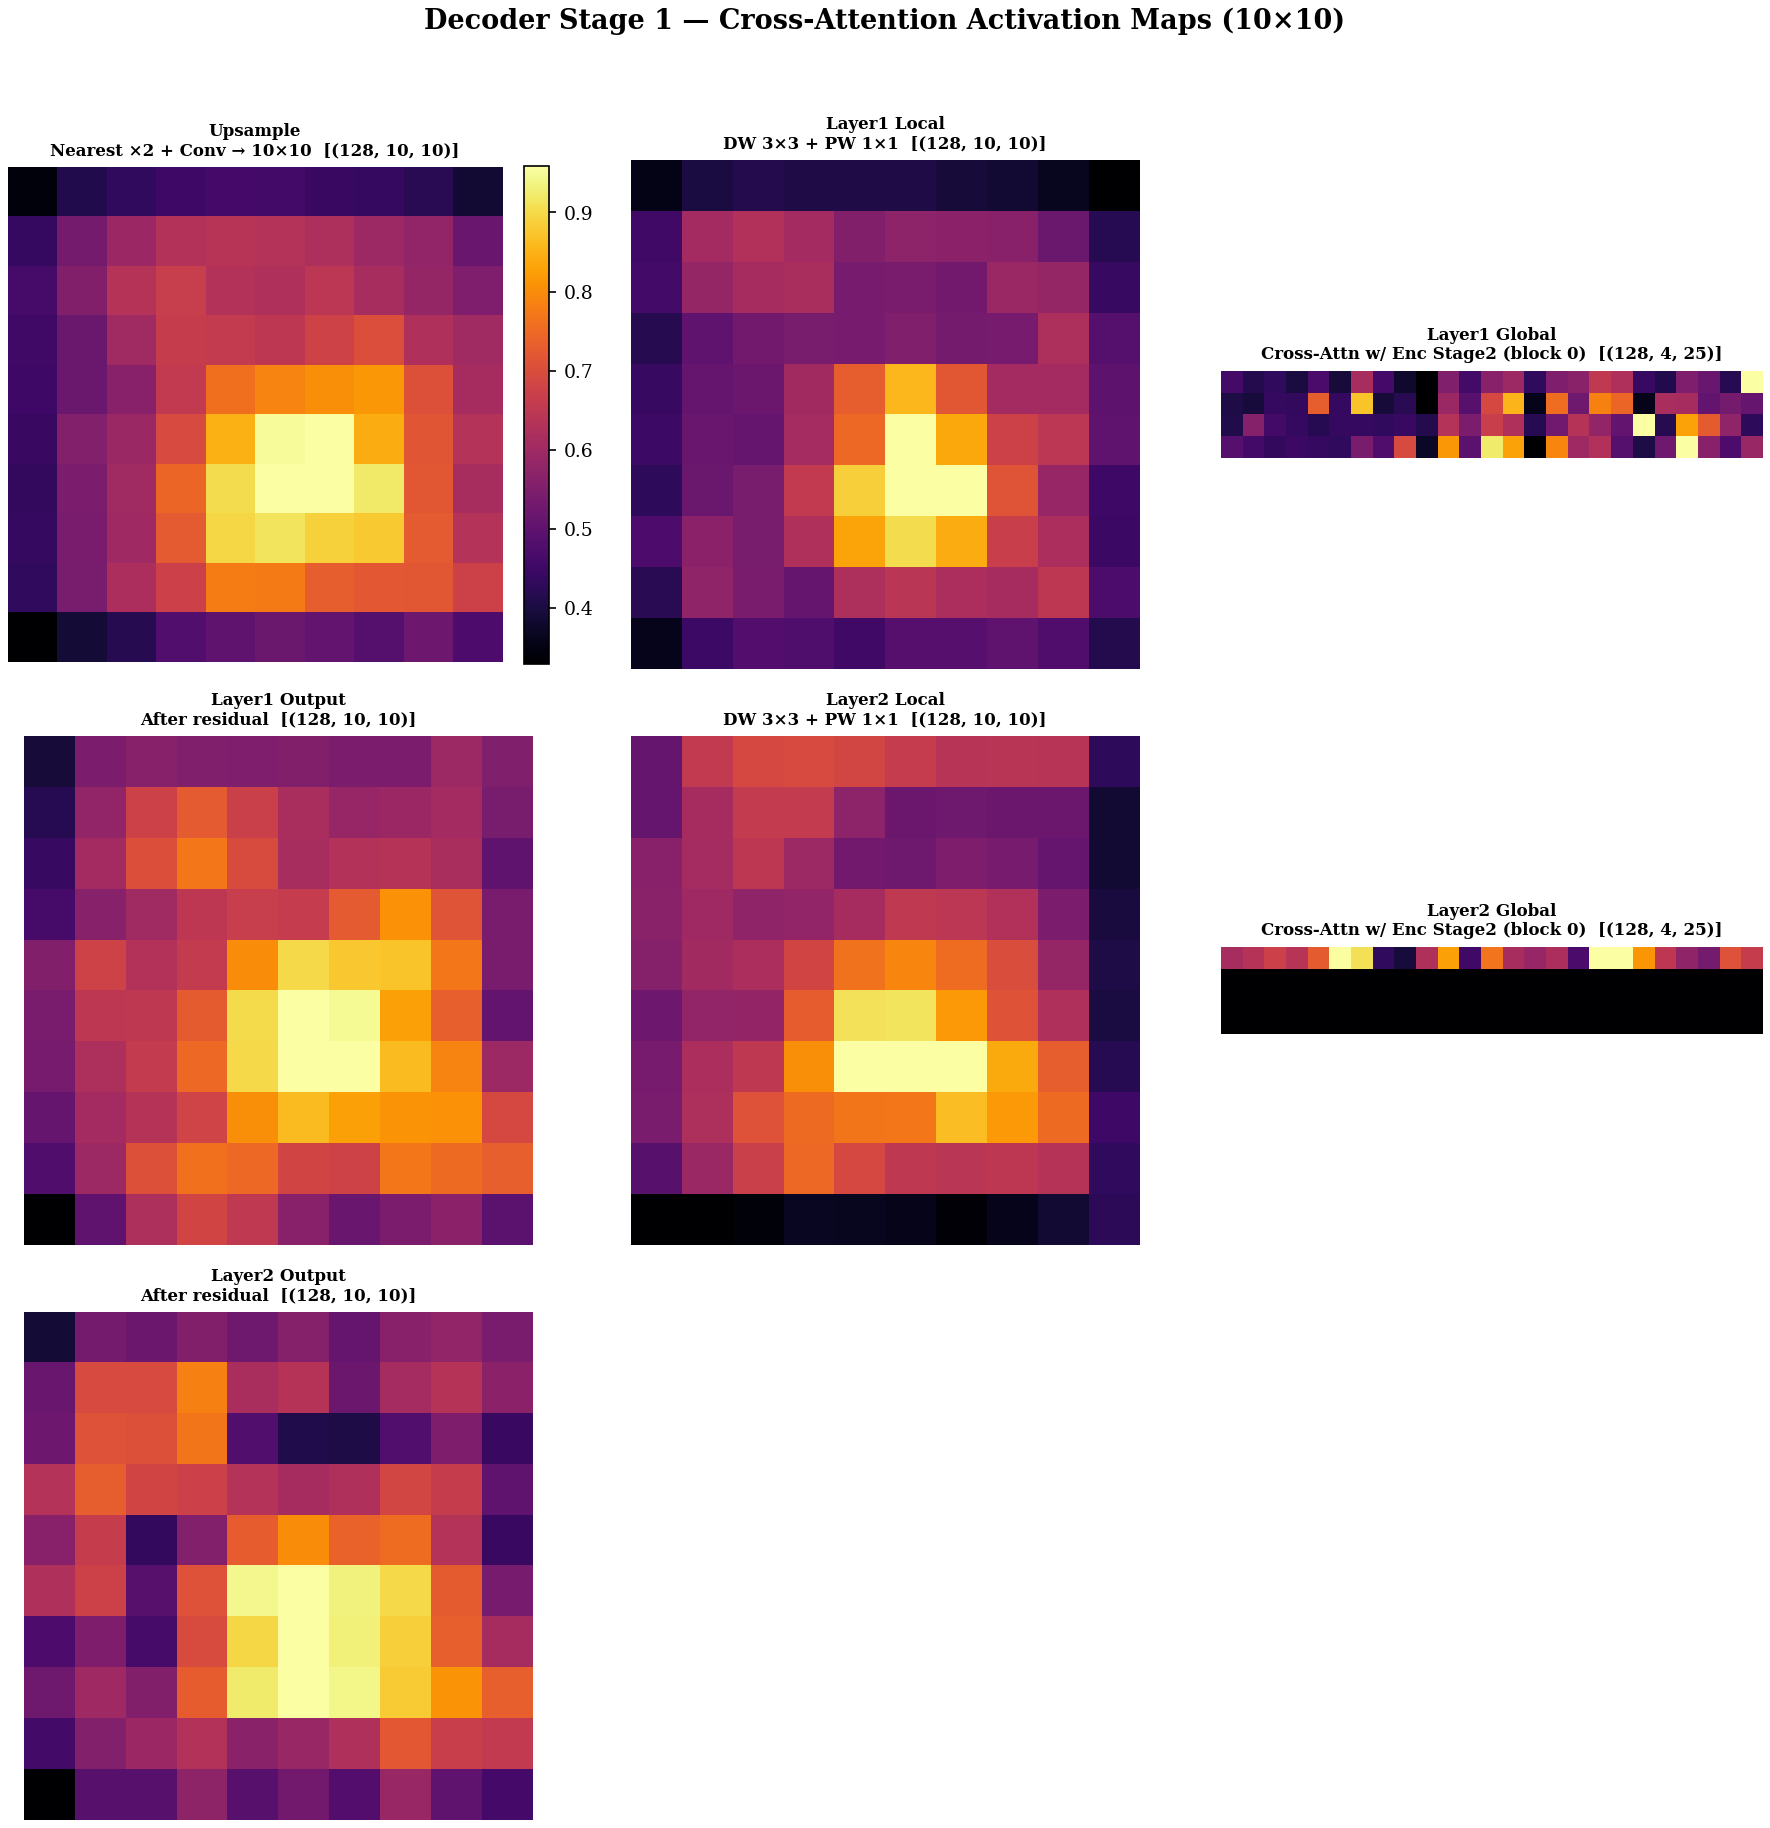

In [37]:
# ── Decoder Stage 1 ──
dec1_keys = [
    ("decoder.stage1.upsample",        "Upsample",      "Nearest ×2 + Conv → 10×10"),
    ("decoder.stage1.layer1.local",    "Layer1 Local",   "DW 3×3 + PW 1×1"),
    ("decoder.stage1.layer1.global.t0",   "Layer1 Global",  "Cross-Attn w/ Enc Stage2 (block 0)"),
    ("decoder.stage1.layer1.output",   "Layer1 Output",  "After residual"),
    ("decoder.stage1.layer2.local",    "Layer2 Local",   "DW 3×3 + PW 1×1"),
    ("decoder.stage1.layer2.global.t0",   "Layer2 Global",  "Cross-Attn w/ Enc Stage2 (block 0)"),
    ("decoder.stage1.layer2.output",   "Layer2 Output",  "After residual"),
]

plot_side_by_side_heatmaps(
    activations, dec1_keys,
    suptitle="Decoder Stage 1 — Cross-Attention Activation Maps (10×10)",
    n_cols=3, figsize_per_cell=4.0,
)
plt.show()

---
## 7B. Decoder Stage 2 — Continued Upsampling

**Stage 2**: Upsample ×2 (10→20) + 1× `UMobileViTDecoderLayer` (cross-attention with encoder Stage 1 skip)  
Resolution: 20×20, Channels: 128

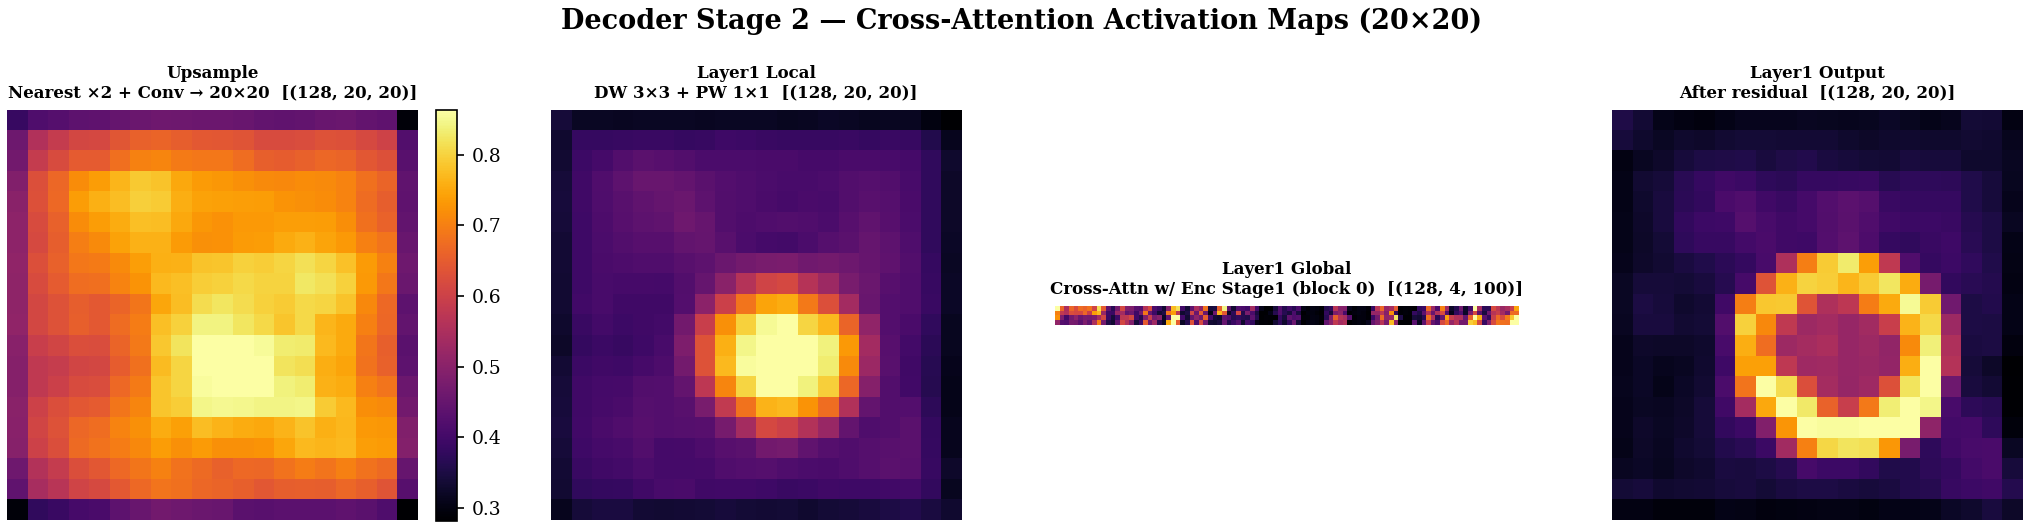

In [38]:
# ── Decoder Stage 2 ──
dec2_keys = [
    ("decoder.stage2.upsample",       "Upsample",       "Nearest ×2 + Conv → 20×20"),
    ("decoder.stage2.layer1.local",   "Layer1 Local",    "DW 3×3 + PW 1×1"),
    ("decoder.stage2.layer1.global.t0",  "Layer1 Global",   "Cross-Attn w/ Enc Stage1 (block 0)"),
    ("decoder.stage2.layer1.output",  "Layer1 Output",   "After residual"),
]

plot_side_by_side_heatmaps(
    activations, dec2_keys,
    suptitle="Decoder Stage 2 — Cross-Attention Activation Maps (20×20)",
    n_cols=4, figsize_per_cell=3.5,
)
plt.show()

---
## 7C. Decoder Out Block — Additive Memory Fusion

**Out Block**: Upsample ×2 (20→40) + 1× `UMobileViTDecoderConcatLayer`  
The ConcatLayer uses **additive memory projection** (no transformer) to fuse encoder stem[2] features.  
Resolution: 40×40, Channels: 128

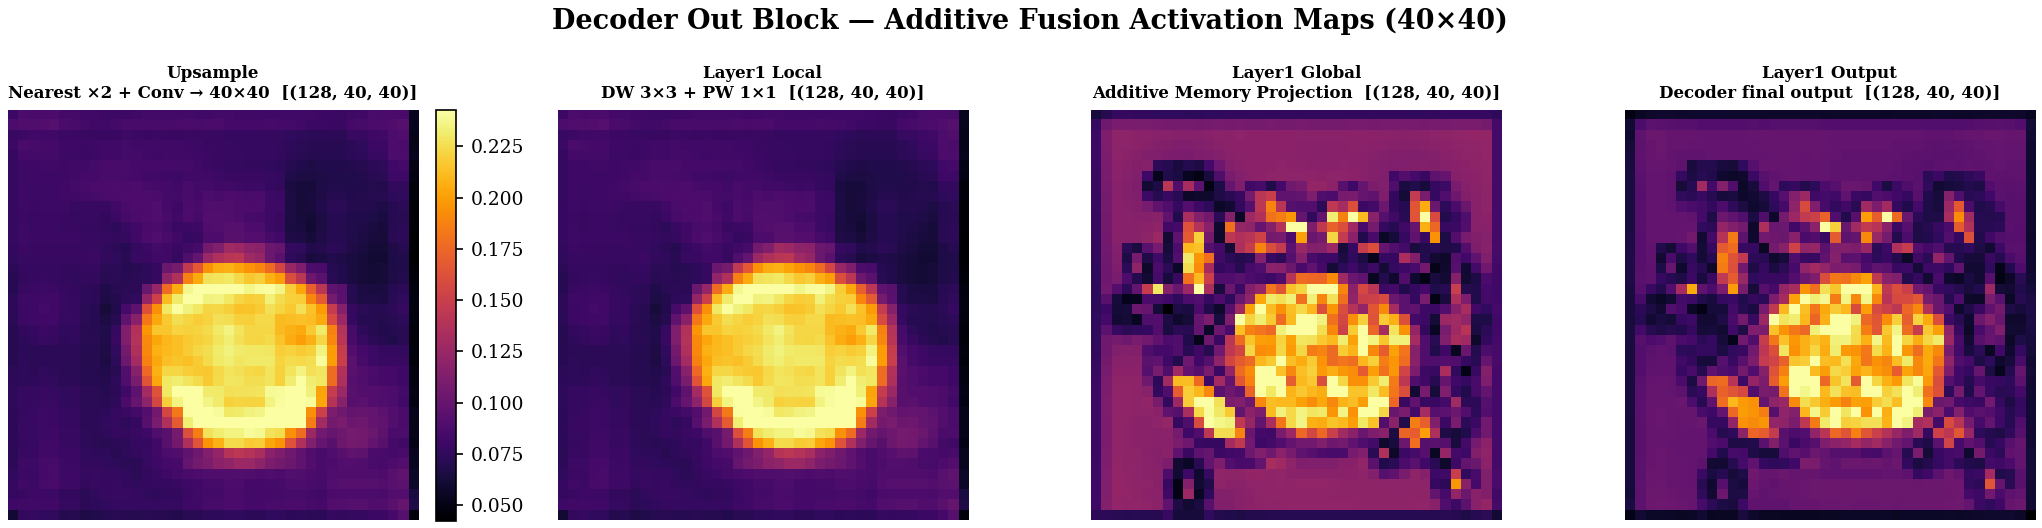

In [39]:
# ── Decoder Out Block ──
dec_out_keys = [
    ("decoder.out.upsample",          "Upsample",       "Nearest ×2 + Conv → 40×40"),
    ("decoder.out.layer1.local",      "Layer1 Local",    "DW 3×3 + PW 1×1"),
    ("decoder.out.layer1.global",     "Layer1 Global",   "Additive Memory Projection"),
    ("decoder.out.layer1.output",     "Layer1 Output",   "Decoder final output"),
]

plot_side_by_side_heatmaps(
    activations, dec_out_keys,
    suptitle="Decoder Out Block — Additive Fusion Activation Maps (40×40)",
    n_cols=4, figsize_per_cell=3.5,
)
plt.show()

---
## 7D. Decoder — Cross-Stage Comparison

How do features evolve through the decoder?

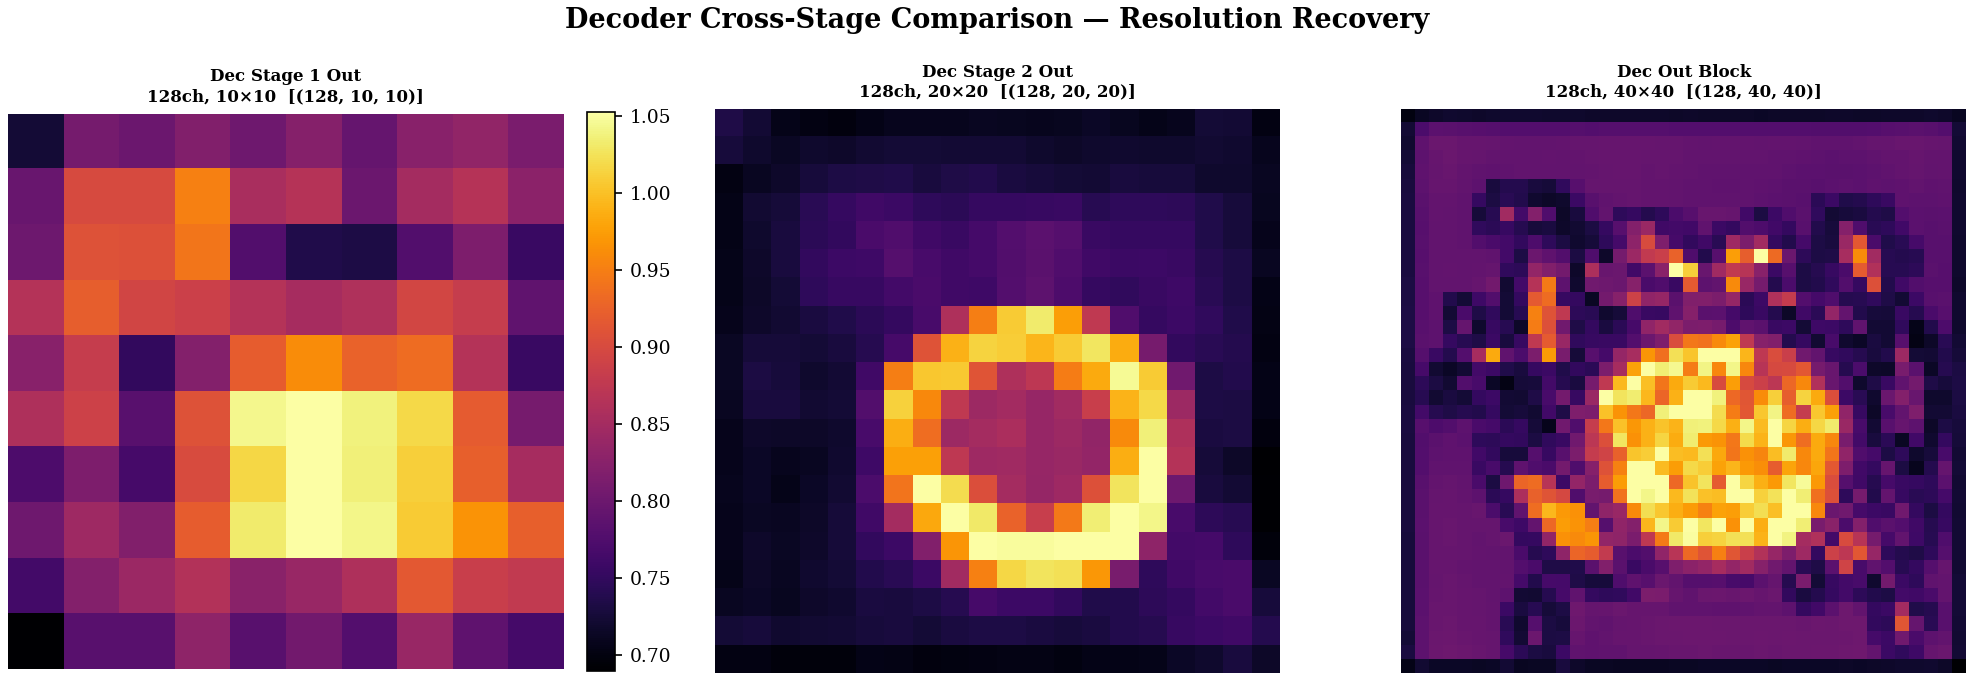

In [40]:
# Cross-stage decoder comparison
dec_cross_keys = [
    ("decoder.stage1.layer2.output",  "Dec Stage 1 Out",  "128ch, 10×10"),
    ("decoder.stage2.layer1.output",  "Dec Stage 2 Out",  "128ch, 20×20"),
    ("decoder.out.layer1.output",     "Dec Out Block",    "128ch, 40×40"),
]

plot_side_by_side_heatmaps(
    activations, dec_cross_keys,
    suptitle="Decoder Cross-Stage Comparison — Resolution Recovery",
    n_cols=3, figsize_per_cell=4.5,
)
plt.show()

---
## 8A. Segmentation Head — Upsample Pathway

The `UpsampleHead` progressively restores spatial resolution with skip connections  
from encoder stem outputs:
- **x2**: 128→64ch, 40→80 (concat with stem[1] 64ch)
- **x4**:  64→32ch, 80→160 (concat with stem[0] 32ch)
- **x8**:  32→16ch, 160→320 (final)

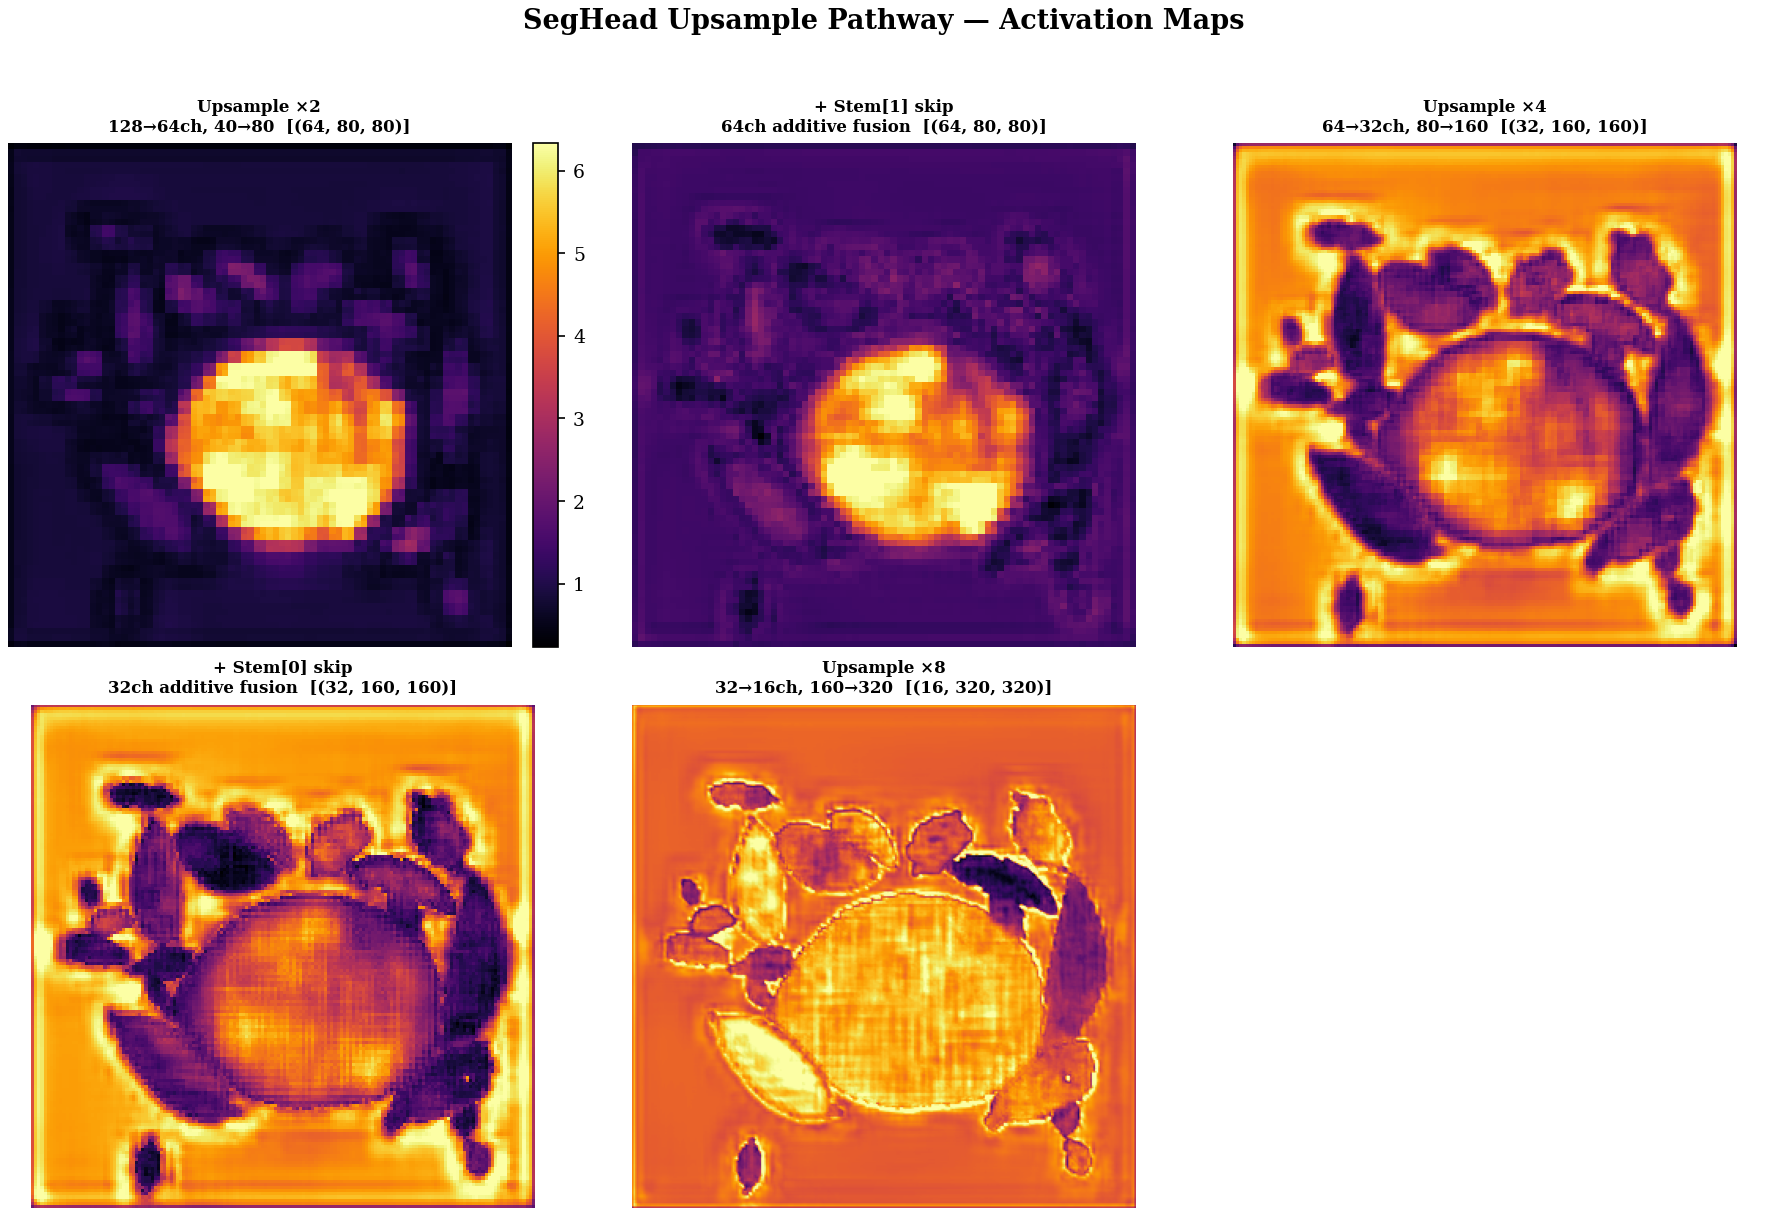

In [41]:
# ── SegHead Upsample stages ──
seghead_keys = [
    ("seg_head.upsample_x2",           "Upsample ×2",    "128→64ch, 40→80"),
    ("seg_head.upsample_x2.concat1",   "+ Stem[1] skip", "64ch additive fusion"),
    ("seg_head.upsample_x4",           "Upsample ×4",    "64→32ch, 80→160"),
    ("seg_head.upsample_x4.concat1",   "+ Stem[0] skip", "32ch additive fusion"),
    ("seg_head.upsample_x8",           "Upsample ×8",    "32→16ch, 160→320"),
]

plot_side_by_side_heatmaps(
    activations, seghead_keys,
    suptitle="SegHead Upsample Pathway — Activation Maps",
    n_cols=3, figsize_per_cell=4.0,
)
plt.show()

---
## 8B. Feature Refinement & Final Classifier

**Refinement Block**: Dilated Conv (d=2) + Spatial Attention (avg/max pooling → Conv7×7 → Sigmoid)  
**Classifier**: Depthwise 3×3 → ReLU → Pointwise 1×1 → logits (8 classes)

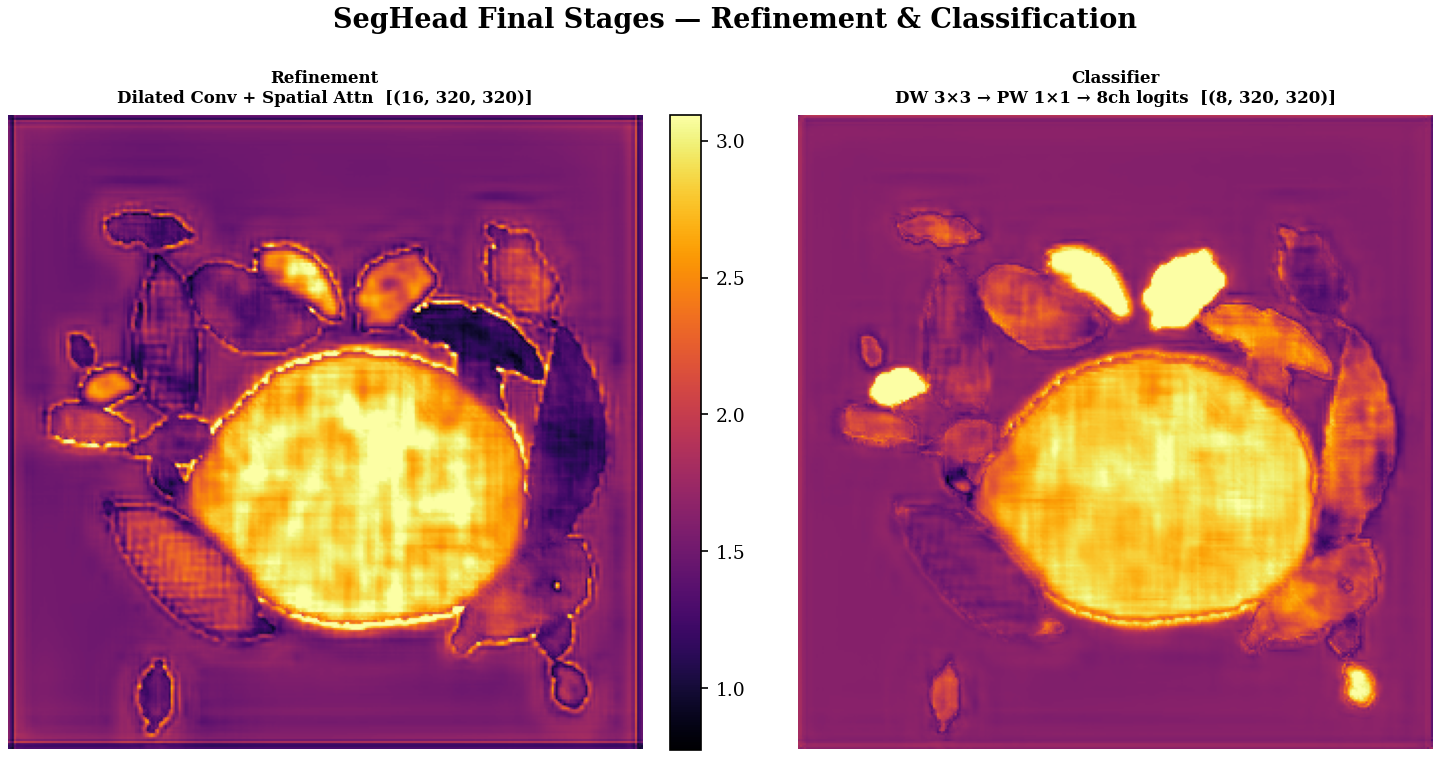

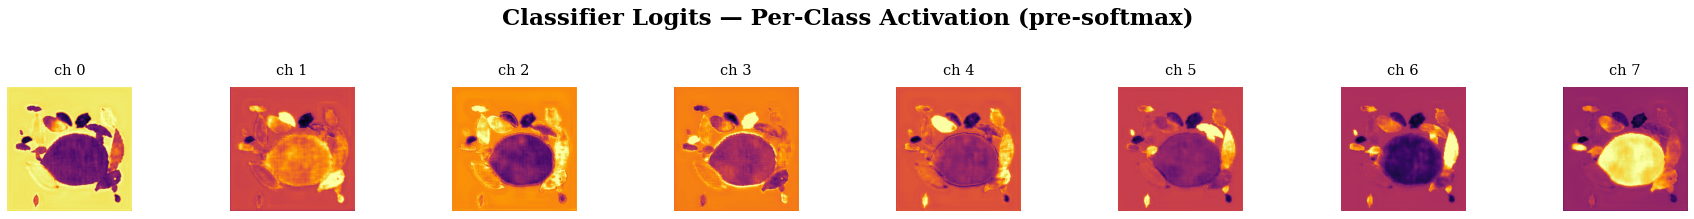

In [42]:
# ── Refinement + Classifier ──
head_final_keys = [
    ("seg_head.refinement",            "Refinement",      "Dilated Conv + Spatial Attn"),
    ("seg_head.classifier",            "Classifier",      "DW 3×3 → PW 1×1 → 8ch logits"),
]

plot_side_by_side_heatmaps(
    activations, head_final_keys,
    suptitle="SegHead Final Stages — Refinement & Classification",
    n_cols=2, figsize_per_cell=5.0,
)
plt.show()

# Also show per-channel classifier logits
if "seg_head.classifier" in activations:
    fig = channel_heatmap_grid(
        activations["seg_head.classifier"],
        n_cols=8,
        title="Classifier Logits — Per-Class Activation (pre-softmax)",
        figsize_scale=1.5,
    )
    plt.show()

---
## 9. End-to-End Feature Evolution — Comprehensive View

A single figure showing the channel-mean activation at every major pipeline stage,  
from input to output. This gives a complete picture of how the representation evolves.

Saved: paper_figures/05_feature_evolution.pdf


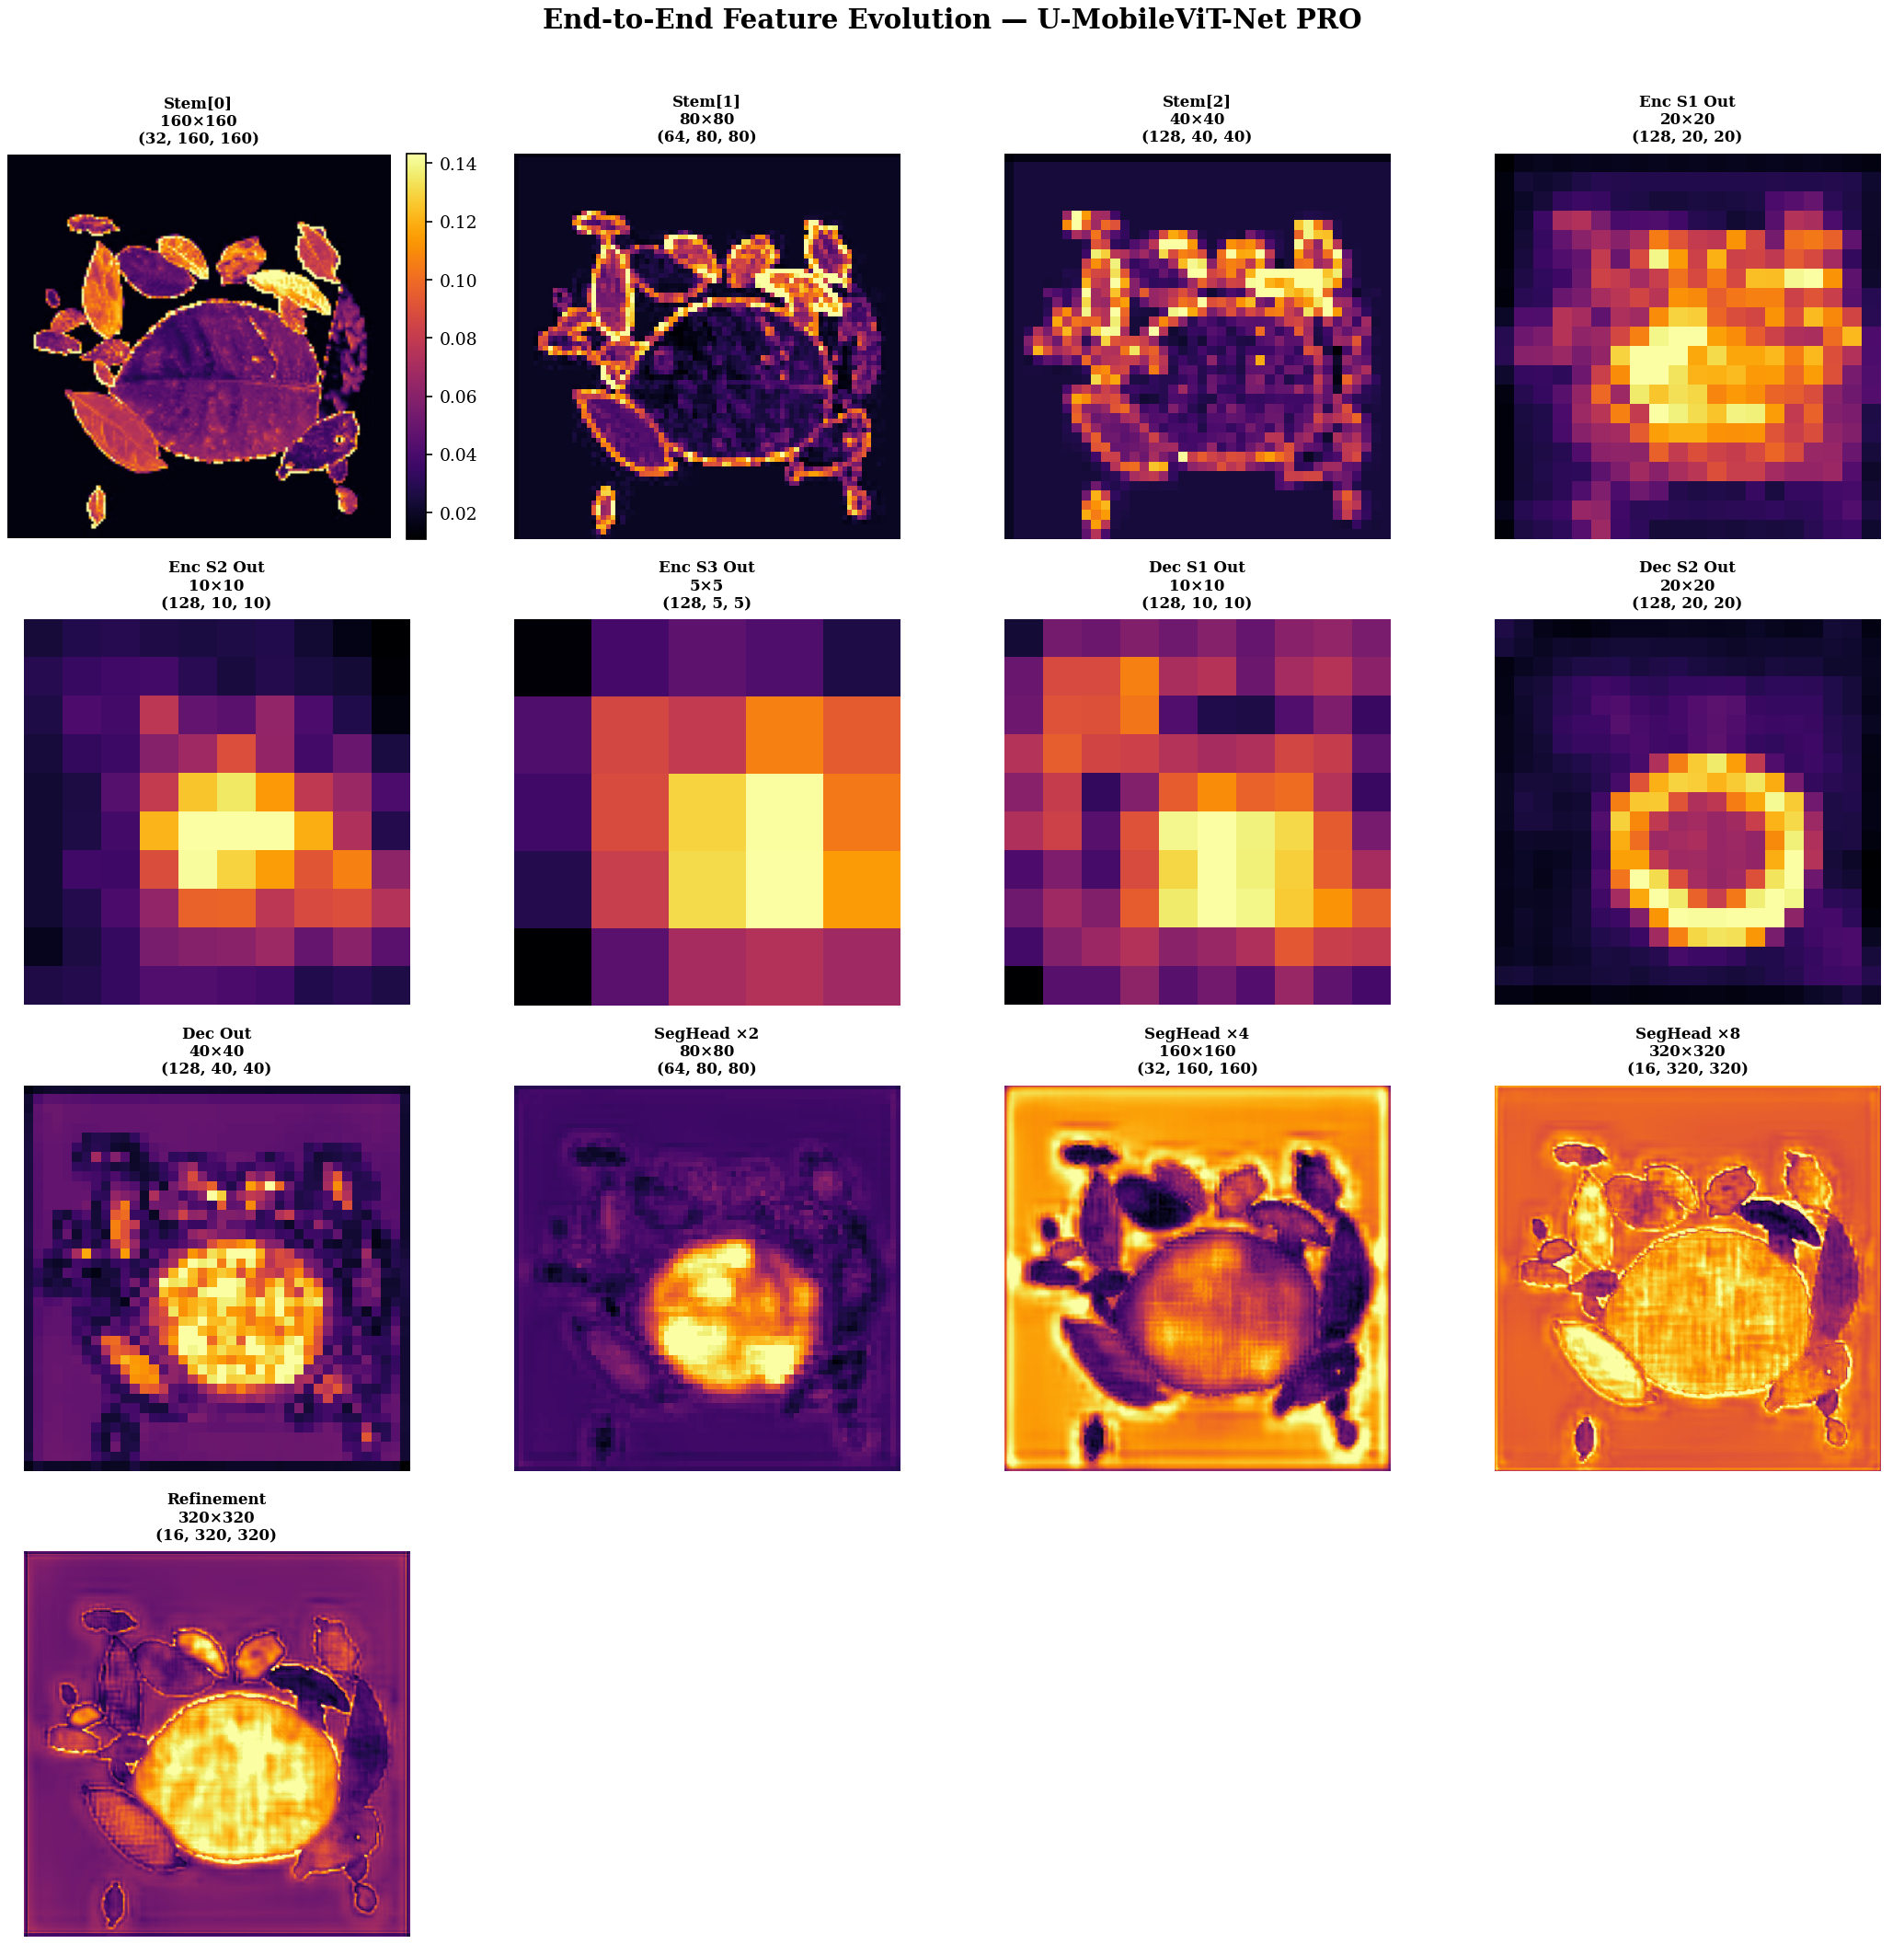

In [43]:
# ── Full pipeline overview ──
pipeline_keys = [
    "encoder.stem[0]",
    "encoder.stem[1]",
    "encoder.stem[2]",
    "encoder.stage1.layer1.output",
    "encoder.stage2.layer2.output",
    "encoder.stage3.layer2.output",
    "decoder.stage1.layer2.output",
    "decoder.stage2.layer1.output",
    "decoder.out.layer1.output",
    "seg_head.upsample_x2.concat1",
    "seg_head.upsample_x4.concat1",
    "seg_head.upsample_x8",
    "seg_head.refinement",
]

pipeline_labels = [
    "Stem[0]\n160×160",
    "Stem[1]\n80×80",
    "Stem[2]\n40×40",
    "Enc S1 Out\n20×20",
    "Enc S2 Out\n10×10",
    "Enc S3 Out\n5×5",
    "Dec S1 Out\n10×10",
    "Dec S2 Out\n20×20",
    "Dec Out\n40×40",
    "SegHead ×2\n80×80",
    "SegHead ×4\n160×160",
    "SegHead ×8\n320×320",
    "Refinement\n320×320",
]

valid_keys = [k for k in pipeline_keys if k in activations]
valid_labels = [lbl for k, lbl in zip(pipeline_keys, pipeline_labels) if k in activations]

n_cols = 4
n_rows = int(np.ceil(len(valid_keys) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
axes = axes.flatten()

for i, (key, label) in enumerate(zip(valid_keys, valid_labels)):
    tensor = activations[key]
    shape_str = f"{tuple(tensor.shape[1:])}"
    activation_heatmap(tensor, axes[i], title=f"{label}\n{shape_str}", show_colorbar=(i == 0))

for j in range(len(valid_keys), len(axes)):
    axes[j].axis("off")

fig.suptitle("End-to-End Feature Evolution — U-MobileViT-Net PRO",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()

# Save for paper
os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_feature_evolution.pdf", bbox_inches="tight", dpi=150)
print("Saved: paper_figures/05_feature_evolution.pdf")
plt.show()

---
## 10. Prediction vs Ground Truth

Verify the model is producing sensible predictions on this sample.

Saved: paper_figures/05_prediction_vs_gt.pdf


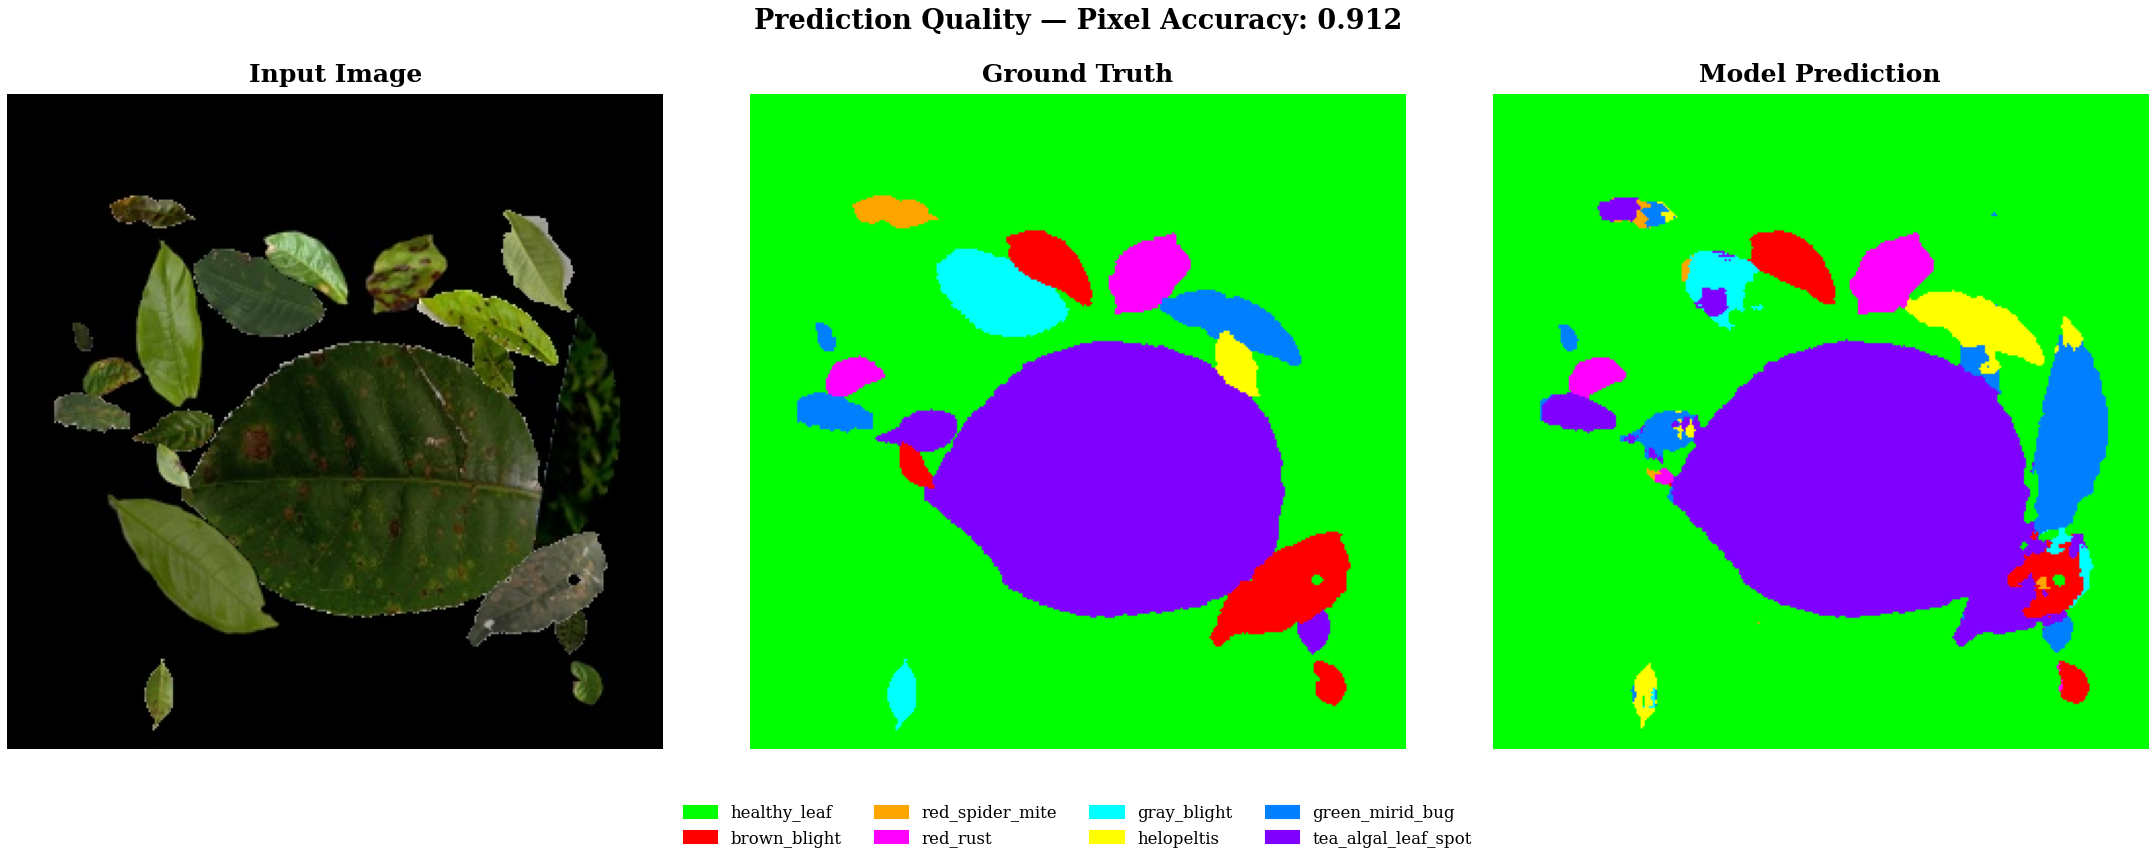

In [44]:
# --- Section 10: Prediction vs Ground Truth -------------------------------------

# ── Prediction vs GT ──
with torch.no_grad():
    logits = model(img_gpu)
    pred = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Input image (denormalize returns (H, W, C) numpy)
img_np = denormalize(sample_img[0])
axes[0].imshow(img_np)
axes[0].set_title("Input Image", fontweight="bold", fontsize=12)
axes[0].axis("off")

# Ground truth
gt = sample_mask[0].numpy()
axes[1].imshow(label_to_color(gt, info.palette))
axes[1].set_title("Ground Truth", fontweight="bold", fontsize=12)
axes[1].axis("off")

# Prediction
pr = pred[0].numpy()
axes[2].imshow(label_to_color(pr, info.palette))
axes[2].set_title("Model Prediction", fontweight="bold", fontsize=12)
axes[2].axis("off")

# Legend
palette_01 = info.palette / 255.0
patches = [mpatches.Patch(color=palette_01[i], label=name)
           for i, name in enumerate(info.class_names)]
fig.legend(handles=patches, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.12), fontsize=8)

# IoU stats
intersection = (pr == gt) & (gt != info.ignore_index)
union = (pr != info.ignore_index) | (gt != info.ignore_index)
pixel_acc = intersection.sum() / max(union.sum(), 1)
fig.suptitle(f"Prediction Quality — Pixel Accuracy: {pixel_acc:.3f}",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()

os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_prediction_vs_gt.pdf", bbox_inches="tight", dpi=150)
print("Saved: paper_figures/05_prediction_vs_gt.pdf")
plt.show()

---
## 11. Per-Stage Activation Statistics

Quantitative summary: mean, std, sparsity (fraction of near-zero activations)  
for each major stage. This reveals how activation patterns change through the network.

Layer                                                     Mean         Std    Sparsity                 Shape
--------------------------------------------------------------------------------------------------------------
  encoder.stem[0]                                       0.0360      0.0806      0.000     (1, 32, 160, 160)
  encoder.stem[1]                                       0.0629      0.8817      0.031       (1, 64, 80, 80)
  encoder.stem[2]                                       0.0448      0.9125      0.000      (1, 128, 40, 40)
  encoder.stage1.downsample                             0.4153      0.8162      0.000      (1, 128, 20, 20)
  encoder.stage1.layer1.local                           0.0457      0.9429      0.000      (1, 128, 20, 20)
  encoder.stage1.layer1.global.t0                       0.0034      0.9321      0.000      (1, 128, 4, 100)
  encoder.stage1.layer1.expansion                       0.0231      1.1913      0.000      (1, 128, 20, 20)
  encoder.stage1.layer1.

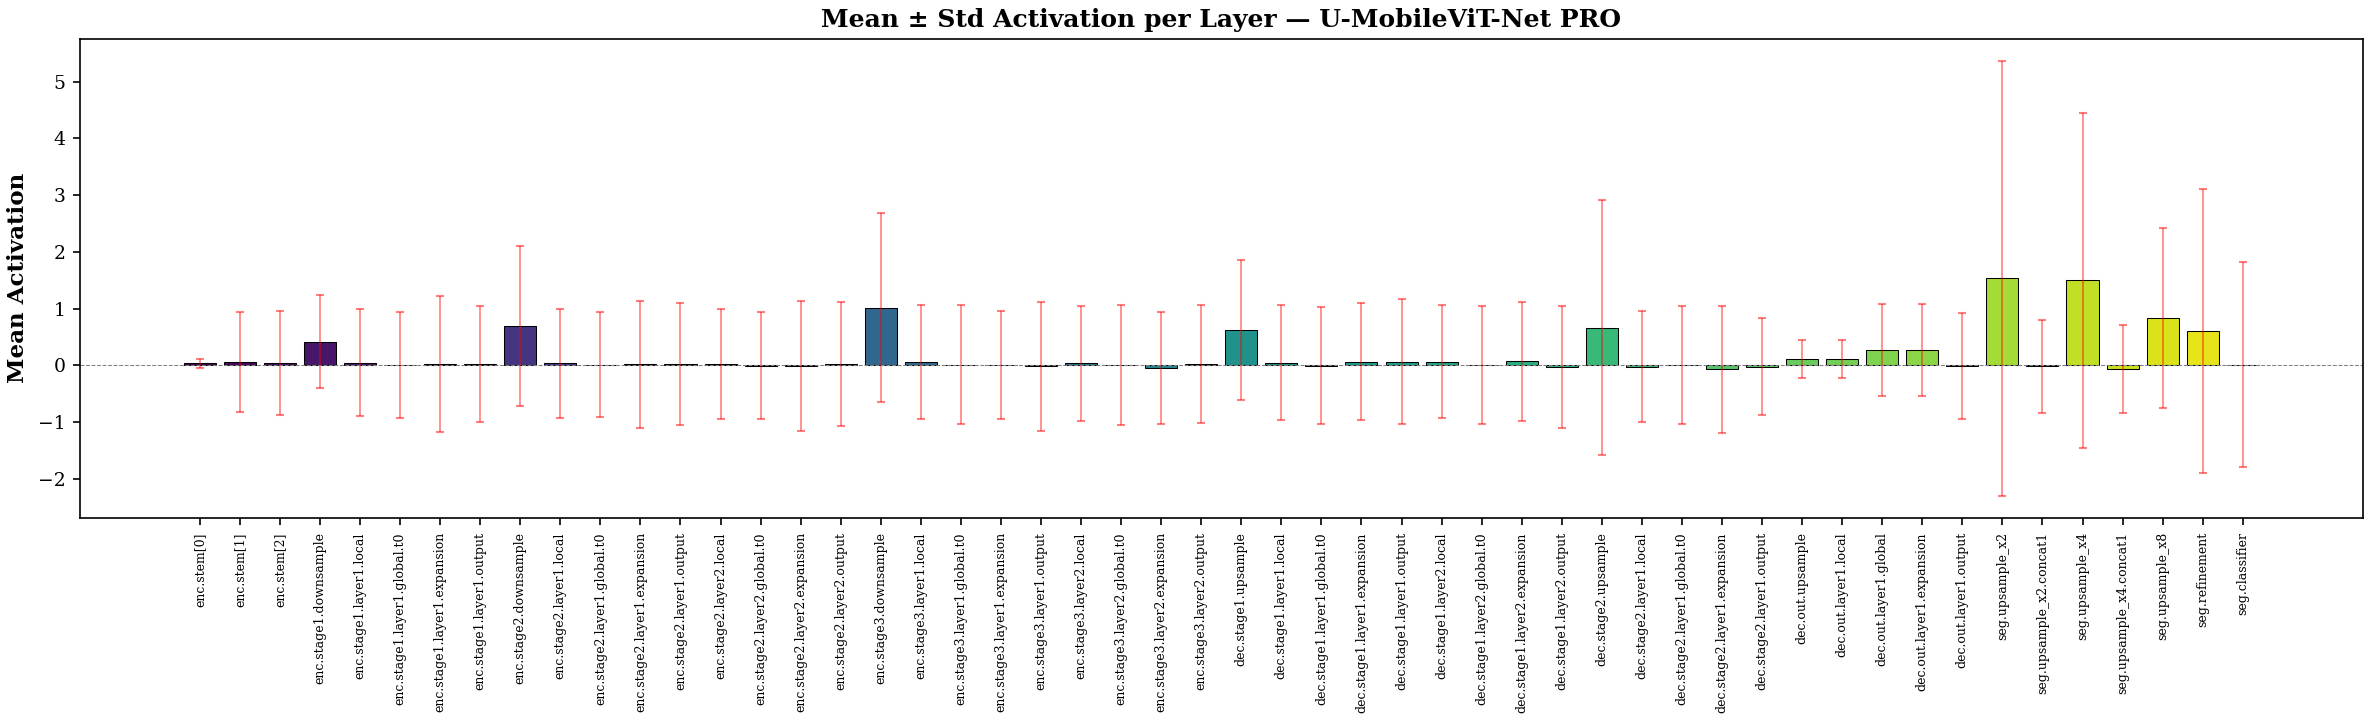

In [45]:
# ── Activation statistics ──
print(f"{'Layer':<50s}  {'Mean':>10s}  {'Std':>10s}  {'Sparsity':>10s}  {'Shape':>20s}")
print("-" * 110)

stats_data = []
for name, tensor in activations.items():
    t = tensor.float()
    mean_val = t.mean().item()
    std_val = t.std().item()
    # Sparsity: fraction of channels where absolute activation < 1% of max
    ch_max = t[0].abs().amax(dim=(1, 2))  # per-channel max
    sparsity = (ch_max < 0.01 * ch_max.max()).float().mean().item()
    shape_str = str(tuple(t.shape))
    print(f"  {name:<48s}  {mean_val:>10.4f}  {std_val:>10.4f}  {sparsity:>9.3f}  {shape_str:>20s}")
    stats_data.append((name, mean_val, std_val, sparsity, t.shape))

# Plot mean activation by stage
fig, ax = plt.subplots(figsize=(16, 5))
names_short = [s[0].replace("encoder.", "enc.").replace("decoder.", "dec.").replace("seg_head.", "seg.")[:45]
               for s in stats_data]
means = [s[1] for s in stats_data]
stds = [s[2] for s in stats_data]

x = np.arange(len(names_short))
bars = ax.bar(x, means, color=[plt.cm.viridis(i / len(x)) for i in range(len(x))], edgecolor="black", linewidth=0.5)
ax.errorbar(x, means, yerr=stds, fmt="none", ecolor="red", capsize=2, alpha=0.5, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names_short, rotation=90, fontsize=6)
ax.set_ylabel("Mean Activation", fontweight="bold")
ax.set_title("Mean ± Std Activation per Layer — U-MobileViT-Net PRO", fontweight="bold")
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()

os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_activation_statistics.pdf", bbox_inches="tight", dpi=150)
print("\nSaved: paper_figures/05_activation_statistics.pdf")
plt.show()

---
## 12. Global Block Attention Map Analysis

For a selected transformer layer, visualise the attention patterns by comparing  
pre- and post-transformer feature maps. The difference highlights what spatial  
relationships the self/cross-attention is capturing.

Saved: paper_figures/05_attention_delta.pdf


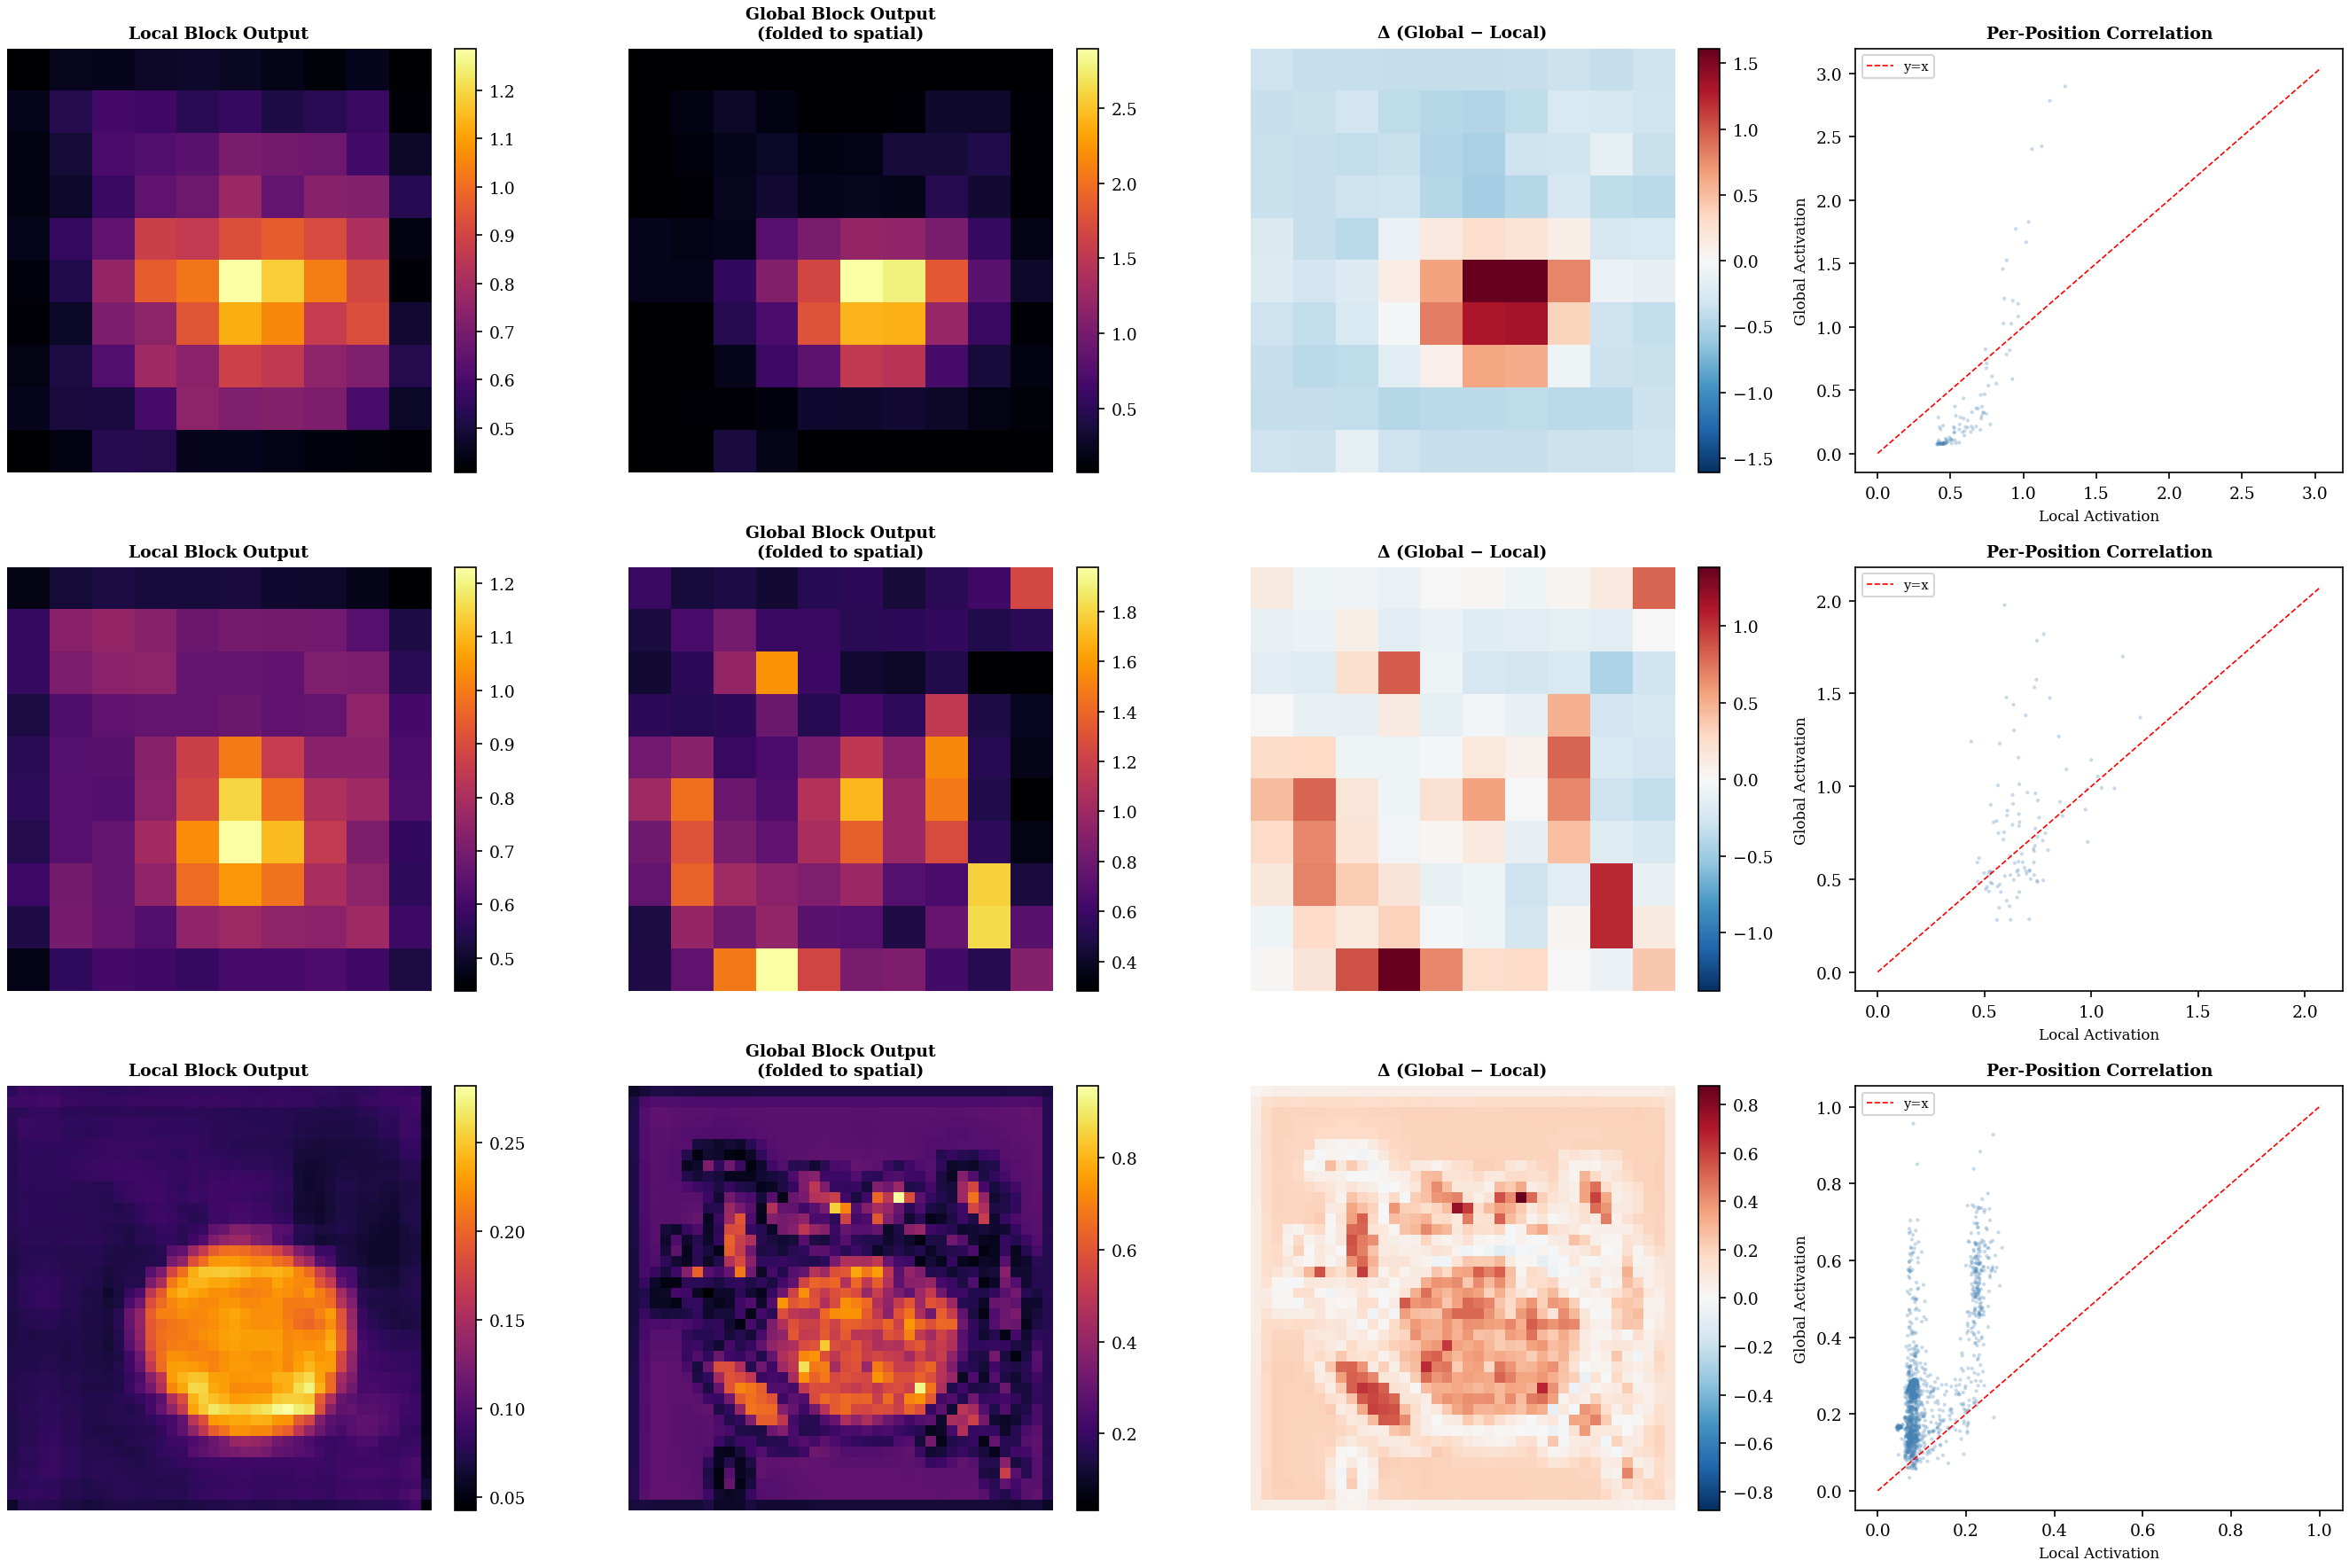

In [46]:
# --- Section 12: Global Block Attention Map Analysis ------------------------------

# ── Attention delta: local → global ──
# Compare local block output vs global (transformer) block output to see what
# attention adds.  Since the transformer operates on UNFOLDED patches, we must
# fold the global activation back to the original spatial grid first.
from cv_nets.utils.functional import fold_custom

# (local_key, global_key, patch_size, title)
attention_pairs = [
    ("encoder.stage2.layer1.local",  "encoder.stage2.layer1.global.t0",
     (2, 2), "Enc S2 L1: Local→Global (Self-Attn)"),
    ("decoder.stage1.layer1.local",  "decoder.stage1.layer1.global.t0",
     (2, 2), "Dec S1 L1: Local→Global (Cross-Attn)"),
    ("decoder.out.layer1.local",     "decoder.out.layer1.global",
     None,   "Dec Out L1: Local→Global (Additive Proj, no unfold)"),
]

fig, axes = plt.subplots(len(attention_pairs), 4, figsize=(18, 4 * len(attention_pairs)))
if len(attention_pairs) == 1:
    axes = axes.reshape(1, -1)

for row, (local_key, global_key, patch_size, title) in enumerate(attention_pairs):
    if local_key not in activations or global_key not in activations:
        for ax in axes[row]:
            ax.axis("off")
        continue

    # Channel-mean of local block output (already in spatial format)
    local_feat = activations[local_key][0].abs().mean(dim=0)  # (H, W)

    # Global block output: fold back to spatial if needed
    global_tensor = activations[global_key]  # (1, C, …)
    if patch_size is not None:
        H_loc, W_loc = local_feat.shape
        global_tensor = fold_custom(global_tensor, output_size=(H_loc, W_loc),
                                     kernel_size=patch_size)
    global_feat = global_tensor[0].abs().mean(dim=0)  # (H, W)

    delta = global_feat - local_feat

    # Local
    im0 = axes[row, 0].imshow(local_feat.numpy(), cmap="inferno")
    axes[row, 0].set_title("Local Block Output", fontsize=9, fontweight="bold")
    axes[row, 0].axis("off")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    # Global (folded)
    im1 = axes[row, 1].imshow(global_feat.numpy(), cmap="inferno")
    axes[row, 1].set_title("Global Block Output\n(folded to spatial)", fontsize=9, fontweight="bold")
    axes[row, 1].axis("off")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    # Delta (diverging colormap)
    vmax = max(abs(delta.min().item()), abs(delta.max().item()))
    im2 = axes[row, 2].imshow(delta.numpy(), cmap="RdBu_r",
                               norm=Normalize(vmin=-vmax, vmax=vmax))
    axes[row, 2].set_title("Δ (Global − Local)", fontsize=9, fontweight="bold")
    axes[row, 2].axis("off")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

    # Scatter: local vs global per spatial position
    axes[row, 3].scatter(local_feat.flatten().numpy(), global_feat.flatten().numpy(),
                          alpha=0.3, s=4, c="steelblue", edgecolors="none")
    lims = [0, max(local_feat.max().item(), global_feat.max().item()) * 1.05]
    axes[row, 3].plot(lims, lims, "r--", linewidth=0.8, label="y=x")
    axes[row, 3].set_xlabel("Local Activation", fontsize=8)
    axes[row, 3].set_ylabel("Global Activation", fontsize=8)
    axes[row, 3].set_title("Per-Position Correlation", fontsize=9, fontweight="bold")
    axes[row, 3].legend(fontsize=7)

    axes[row, 0].set_ylabel(title, fontsize=10, fontweight="bold", rotation=90,
                             labelpad=20, va="center")

plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_attention_delta.pdf", bbox_inches="tight", dpi=150)
print("Saved: paper_figures/05_attention_delta.pdf")
plt.show()

---
## 13. Summary

Key observations from the model dissection:

In [47]:
print("=" * 72)
print("  MODEL DISSECTION SUMMARY | U-MobileViT-Net PRO")
print("=" * 72)
print(f"  Dataset:            {info.name}")
print(f"  Model variant:      {CFG['variant'].upper()}")
print(f"  Parameters:         {n_params:,} ({n_params/1e6:.2f} M)")
print(f"  Input resolution:   {CFG['image_size']}")
print(f"  Classes:            {info.num_classes}")
print(f"  Checkpoint:         {CFG['checkpoint']}")
print(f"  Layers captured:    {len(activations)}")
print()
print("  Architecture breakdown:")
print(f"    Encoder stem:     3 blocks (3→32→64→128 channels)")
print(f"    Encoder stages:   3 stages (1+2+2 encoder layers)")
print(f"    Decoder stages:   3 stages (2+1+1 decoder layers)")
print(f"    SegHead upsample: 3 stages (×2, ×4, ×8)")
print(f"    Refinement:       Dilated Conv + Spatial Attention")
print(f"    Classifier:       DW 3×3 → PW 1×1")
print()
print("  Visualisations saved:")
print("    paper_figures/05_feature_evolution.pdf")
print("    paper_figures/05_prediction_vs_gt.pdf")
print("    paper_figures/05_activation_statistics.pdf")
print("    paper_figures/05_attention_delta.pdf")
print("=" * 72)

  MODEL DISSECTION SUMMARY | U-MobileViT-Net PRO
  Dataset:            COCO Tea Leaf
  Model variant:      PRO
  Parameters:         2,789,675 (2.79 M)
  Input resolution:   (320, 320)
  Classes:            8
  Checkpoint:         checkpoints/coco_leaf/pro/best_model.pth
  Layers captured:    52

  Architecture breakdown:
    Encoder stem:     3 blocks (3→32→64→128 channels)
    Encoder stages:   3 stages (1+2+2 encoder layers)
    Decoder stages:   3 stages (2+1+1 decoder layers)
    SegHead upsample: 3 stages (×2, ×4, ×8)
    Refinement:       Dilated Conv + Spatial Attention
    Classifier:       DW 3×3 → PW 1×1

  Visualisations saved:
    paper_figures/05_feature_evolution.pdf
    paper_figures/05_prediction_vs_gt.pdf
    paper_figures/05_activation_statistics.pdf
    paper_figures/05_attention_delta.pdf
